# การวิเคราะห์ข้อมูล (EDA) และการจัดการค่าที่หายไป — Ecommerce Customer Churn

## 1. นำเข้า Libraries ที่จำเป็น

In [178]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('outputs/figures', exist_ok=True)

os.makedirs('outputs/csv', exist_ok=True)

%matplotlib inline

sns.set_theme(style="whitegrid")

## 2. โหลดชุดข้อมูล

In [179]:
df = pd.read_csv("data/Ecommerce Customer Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## 2.1 สรุปสถิติเชิงพรรณนา (Descriptive Statistics) & Class Imbalance

  DESCRIPTIVE STATISTICS


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.00,5630.00,5366.00,5630.00,5379.00,5375.00,5630.00,5630.00,5630.00,5630.00,5365.00,5374.00,5372.00,5323.00,5630.00
mean,52815.50,0.17,10.19,1.65,15.64,2.93,3.69,3.07,4.21,0.28,15.71,1.75,3.01,4.54,177.22
std,1625.39,0.37,8.56,0.92,8.53,0.72,1.02,1.38,2.58,0.45,3.68,1.89,2.94,3.65,49.19
min,50001.00,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,51408.25,0.00,2.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,146.00
50%,52815.50,0.00,9.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,163.00
75%,54222.75,0.00,16.00,3.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,196.00
max,55630.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,325.00


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/1653072661.py:41: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/1653072661.py:41: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/1653072661.py:41: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/1653072661.py:41: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/1653072661.py:41: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/16530

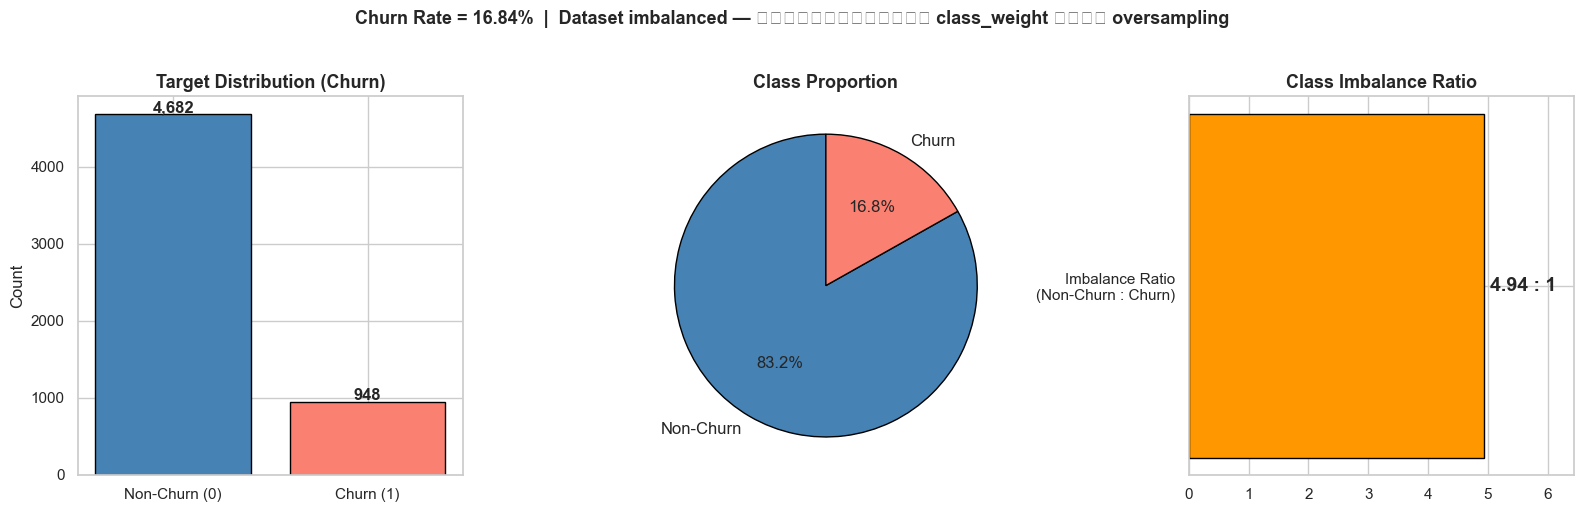


Churn Rate: 16.84%
Non-Churn: 4,682  |  Churn: 948  |  Ratio: 4.94:1


In [180]:
# ---------- Summary Statistics ----------
print("=" * 60)
print("  DESCRIPTIVE STATISTICS")
print("=" * 60)
display(df.describe().round(2))

# ---------- Class Imbalance ----------
churn_counts = df['Churn'].value_counts()
churn_rate   = df['Churn'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Count Bar
bars = axes[0].bar(['Non-Churn (0)', 'Churn (1)'], churn_counts.values,
                    color=['steelblue', 'salmon'], edgecolor='black')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Target Distribution (Churn)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# 2) Pie Chart
axes[1].pie(churn_counts.values,
            labels=['Non-Churn', 'Churn'],
            colors=['steelblue', 'salmon'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='black'),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

# 3) Imbalance Ratio
ratio = churn_counts[0] / churn_counts[1]
axes[2].barh(['Imbalance Ratio\n(Non-Churn : Churn)'], [ratio],
             color='#FF9800', edgecolor='black', height=0.4)
axes[2].text(ratio + 0.1, 0, f'{ratio:.2f} : 1', va='center', fontsize=14, fontweight='bold')
axes[2].set_xlim(0, ratio + 1.5)
axes[2].set_title('Class Imbalance Ratio', fontsize=13, fontweight='bold')

plt.suptitle(f'Churn Rate = {churn_rate:.2%}  |  Dataset imbalanced — ต้องใช้เทคนิค class_weight หรือ oversampling',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nChurn Rate: {churn_rate:.2%}')
print(f'Non-Churn: {churn_counts[0]:,}  |  Churn: {churn_counts[1]:,}  |  Ratio: {ratio:.2f}:1')

## 3. ตรวจสอบค่าที่หายไป (Missing Values)

In [181]:
print("=== dtypes & non-null counts ===")
df.info()

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null 

In [182]:
na_count = df.isnull().sum()
na_pct   = (na_count / len(df) * 100).round(2)
na_summary = pd.DataFrame({"NA Count": na_count, "NA %": na_pct})
na_summary = na_summary[na_summary["NA Count"] > 0].sort_values("NA Count", ascending=False)
print(na_summary)

                             NA Count  NA %
DaySinceLastOrder                 307  5.45
OrderAmountHikeFromlastYear       265  4.71
Tenure                            264  4.69
OrderCount                        258  4.58
CouponUsed                        256  4.55
HourSpendOnApp                    255  4.53
WarehouseToHome                   251  4.46


## 4. แสดงภาพค่าที่หายไป (Missing Data Visualization)

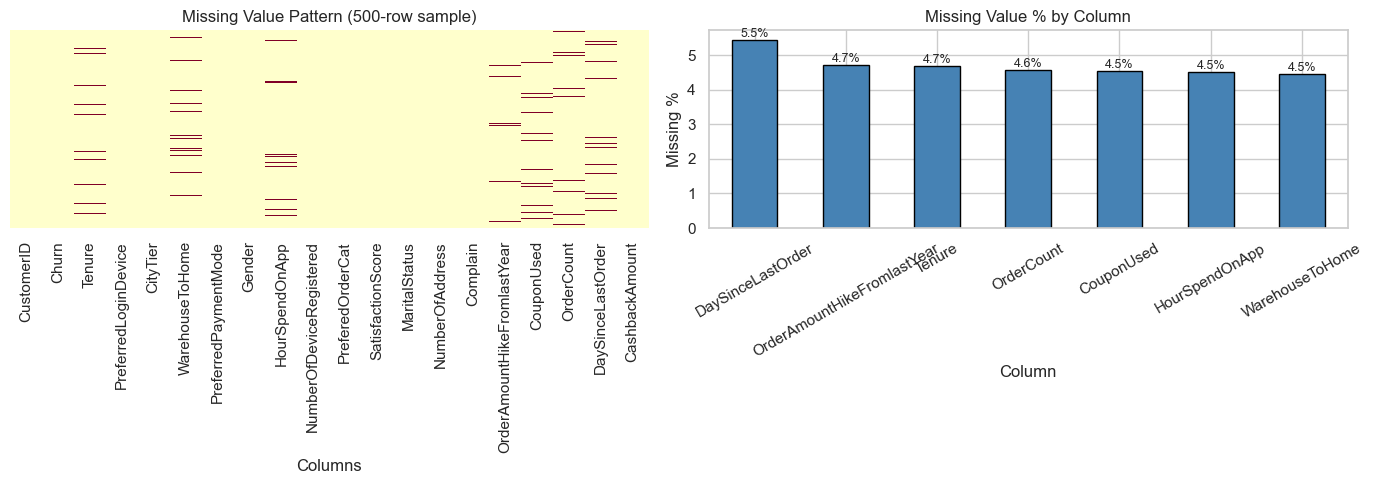

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap (sample 500 rows for readability)
sample = df.sample(500, random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Missing Value Pattern (500-row sample)")
axes[0].set_xlabel("Columns")

# Bar chart
na_summary["NA %"].plot(kind="bar", color="steelblue", edgecolor="black", ax=axes[1])
axes[1].set_title("Missing Value % by Column")
axes[1].set_ylabel("Missing %")
axes[1].set_xlabel("Column")
axes[1].tick_params(axis="x", rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. ทำความสะอาดข้อมูล (Clean Missing Data)

วิธีการ: เติมค่า **median** ลงในทุก column ที่มีค่า NA (robust ต่อ skew และ outlier)

In [184]:
na_cols = na_summary.index.tolist()
print("Columns to fill:", na_cols)

df_clean = df.copy()
for col in na_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled {na_summary.loc[col, 'NA Count']} NAs with median={median_val}")

print(f"\nRemaining NAs after cleaning: {df_clean.isnull().sum().sum()}")

Columns to fill: ['DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'Tenure', 'OrderCount', 'CouponUsed', 'HourSpendOnApp', 'WarehouseToHome']
  DaySinceLastOrder: filled 307 NAs with median=3.0
  OrderAmountHikeFromlastYear: filled 265 NAs with median=15.0
  Tenure: filled 264 NAs with median=9.0
  OrderCount: filled 258 NAs with median=2.0
  CouponUsed: filled 256 NAs with median=1.0
  HourSpendOnApp: filled 255 NAs with median=3.0
  WarehouseToHome: filled 251 NAs with median=14.0

Remaining NAs after cleaning: 0


## 6. เปรียบเทียบข้อมูลก่อนและหลังทำความสะอาด

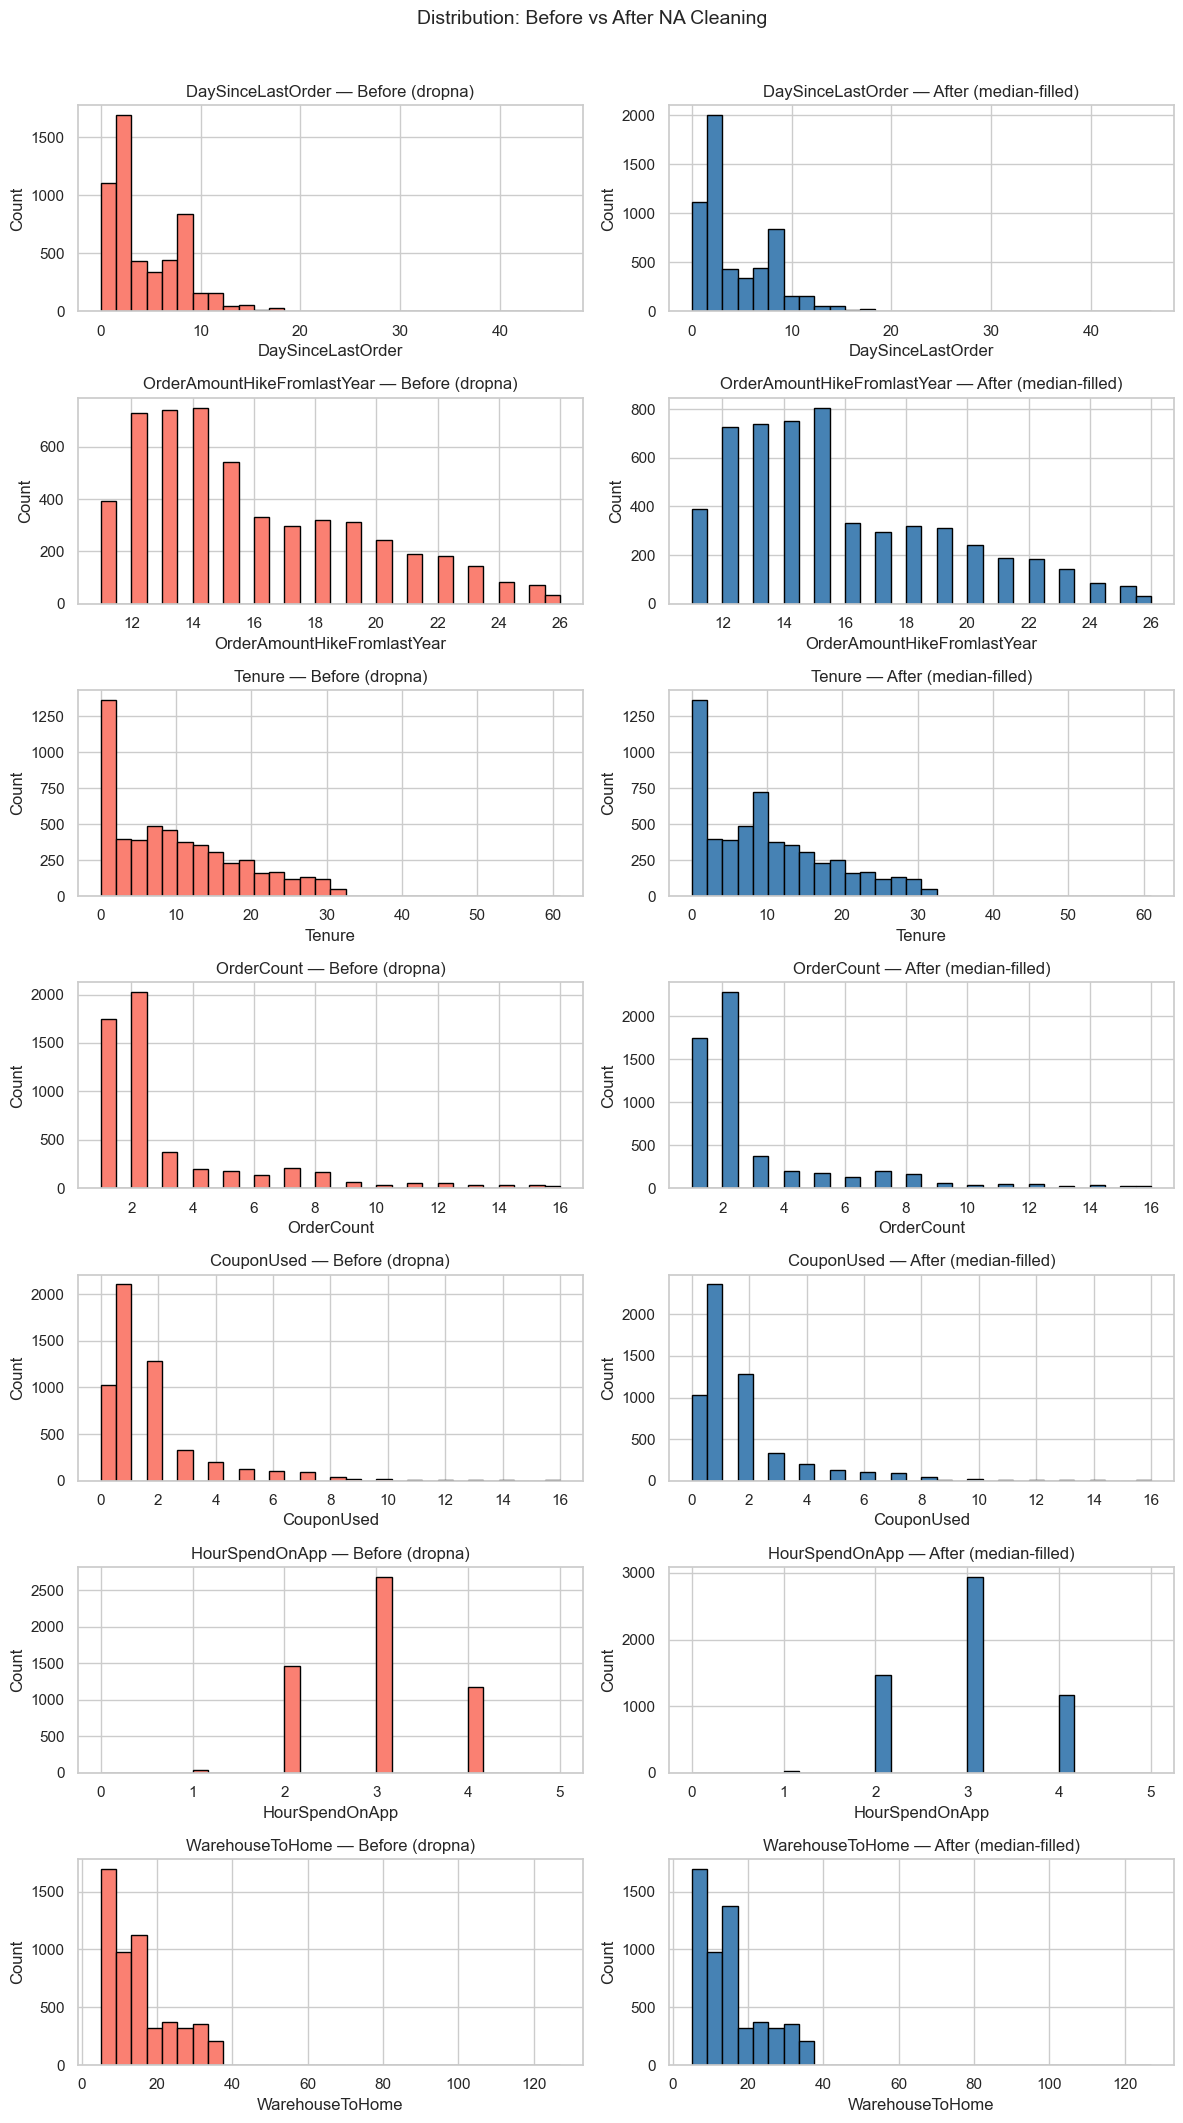

In [185]:
fig, axes = plt.subplots(len(na_cols), 2, figsize=(12, len(na_cols) * 3))

for i, col in enumerate(na_cols):
    # Before
    axes[i, 0].hist(df[col].dropna(), bins=30, color="salmon", edgecolor="black")
    axes[i, 0].set_title(f"{col} — Before (dropna)")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    # After
    axes[i, 1].hist(df_clean[col], bins=30, color="steelblue", edgecolor="black")
    axes[i, 1].set_title(f"{col} — After (median-filled)")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Count")

plt.suptitle("Distribution: Before vs After NA Cleaning", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6.1 Correlation Matrix & Feature ที่สัมพันธ์กับ Churn มากที่สุด

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2681059738.py:35: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2681059738.py:35: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2681059738.py:35: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2681059738.py:35: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2681059738.py:35: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2681059738.

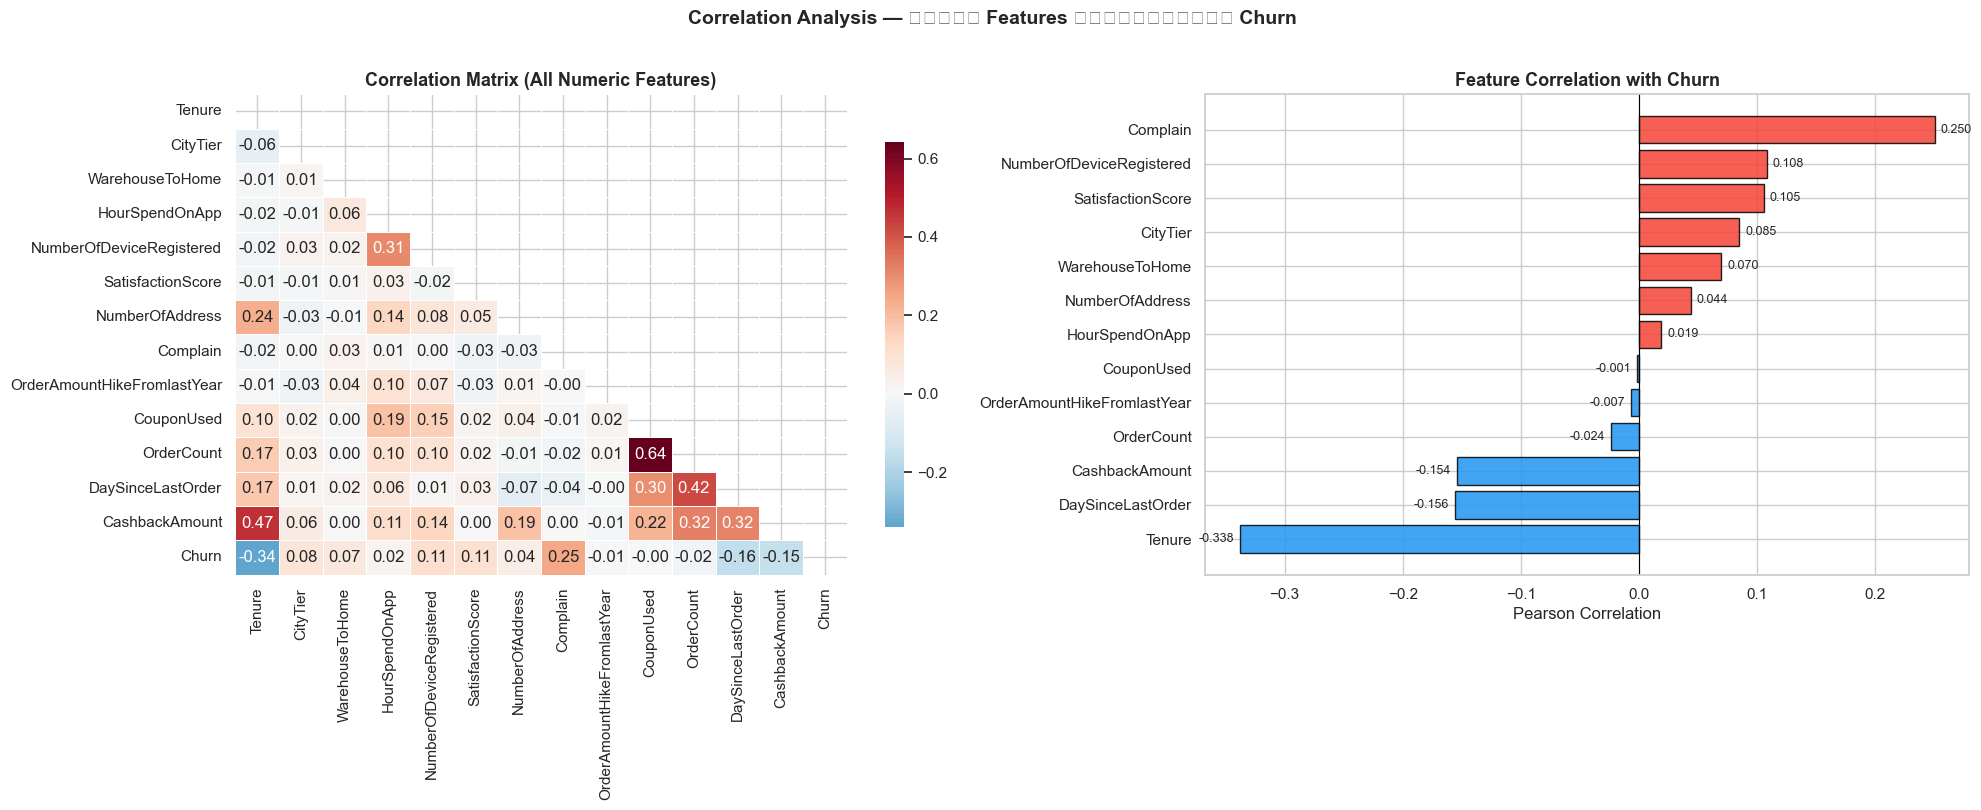

🔴 Top Positive Correlations (เสี่ยง churn สูง):
Complain                    0.250188
NumberOfDeviceRegistered    0.107939
SatisfactionScore           0.105481
CityTier                    0.084703
WarehouseToHome             0.069544
NumberOfAddress             0.043931
HourSpendOnApp              0.018816

🔵 Top Negative Correlations (ลด churn):
Tenure                        -0.337831
DaySinceLastOrder             -0.155871
CashbackAmount                -0.154161
OrderCount                    -0.024038
OrderAmountHikeFromlastYear   -0.007075
CouponUsed                    -0.001430


In [186]:
# ---------- Correlation Heatmap (Numeric Features) ----------
num_for_corr = ['Tenure','CityTier','WarehouseToHome','HourSpendOnApp',
                'NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress',
                'Complain','OrderAmountHikeFromlastYear','CouponUsed',
                'OrderCount','DaySinceLastOrder','CashbackAmount','Churn']

corr = df_clean[num_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1) Full correlation heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, cbar_kws={'shrink': 0.8}, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Correlation Matrix (All Numeric Features)', fontsize=13, fontweight='bold')

# 2) Sorted bar chart: correlation with Churn
churn_corr = corr['Churn'].drop('Churn').sort_values()
colors = ['#F44336' if v > 0 else '#2196F3' for v in churn_corr]
axes[1].barh(churn_corr.index, churn_corr.values, color=colors,
             edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Correlation with Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

# Annotate values
for i, (feat, val) in enumerate(churn_corr.items()):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Correlation Analysis — ค้นหา Features ที่ส่งผลต่อ Churn',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('🔴 Top Positive Correlations (เสี่ยง churn สูง):')
print(churn_corr[churn_corr > 0].sort_values(ascending=False).to_string())
print('\n🔵 Top Negative Correlations (ลด churn):')
print(churn_corr[churn_corr < 0].sort_values().to_string())

## 6.2 Outlier Detection — Box Plots & IQR Analysis

ตรวจสอบ outlier ในแต่ละ feature เชิงตัวเลข เพื่อตัดสินใจว่าควร clip, transform หรือปล่อยไว้ก่อนเข้า model

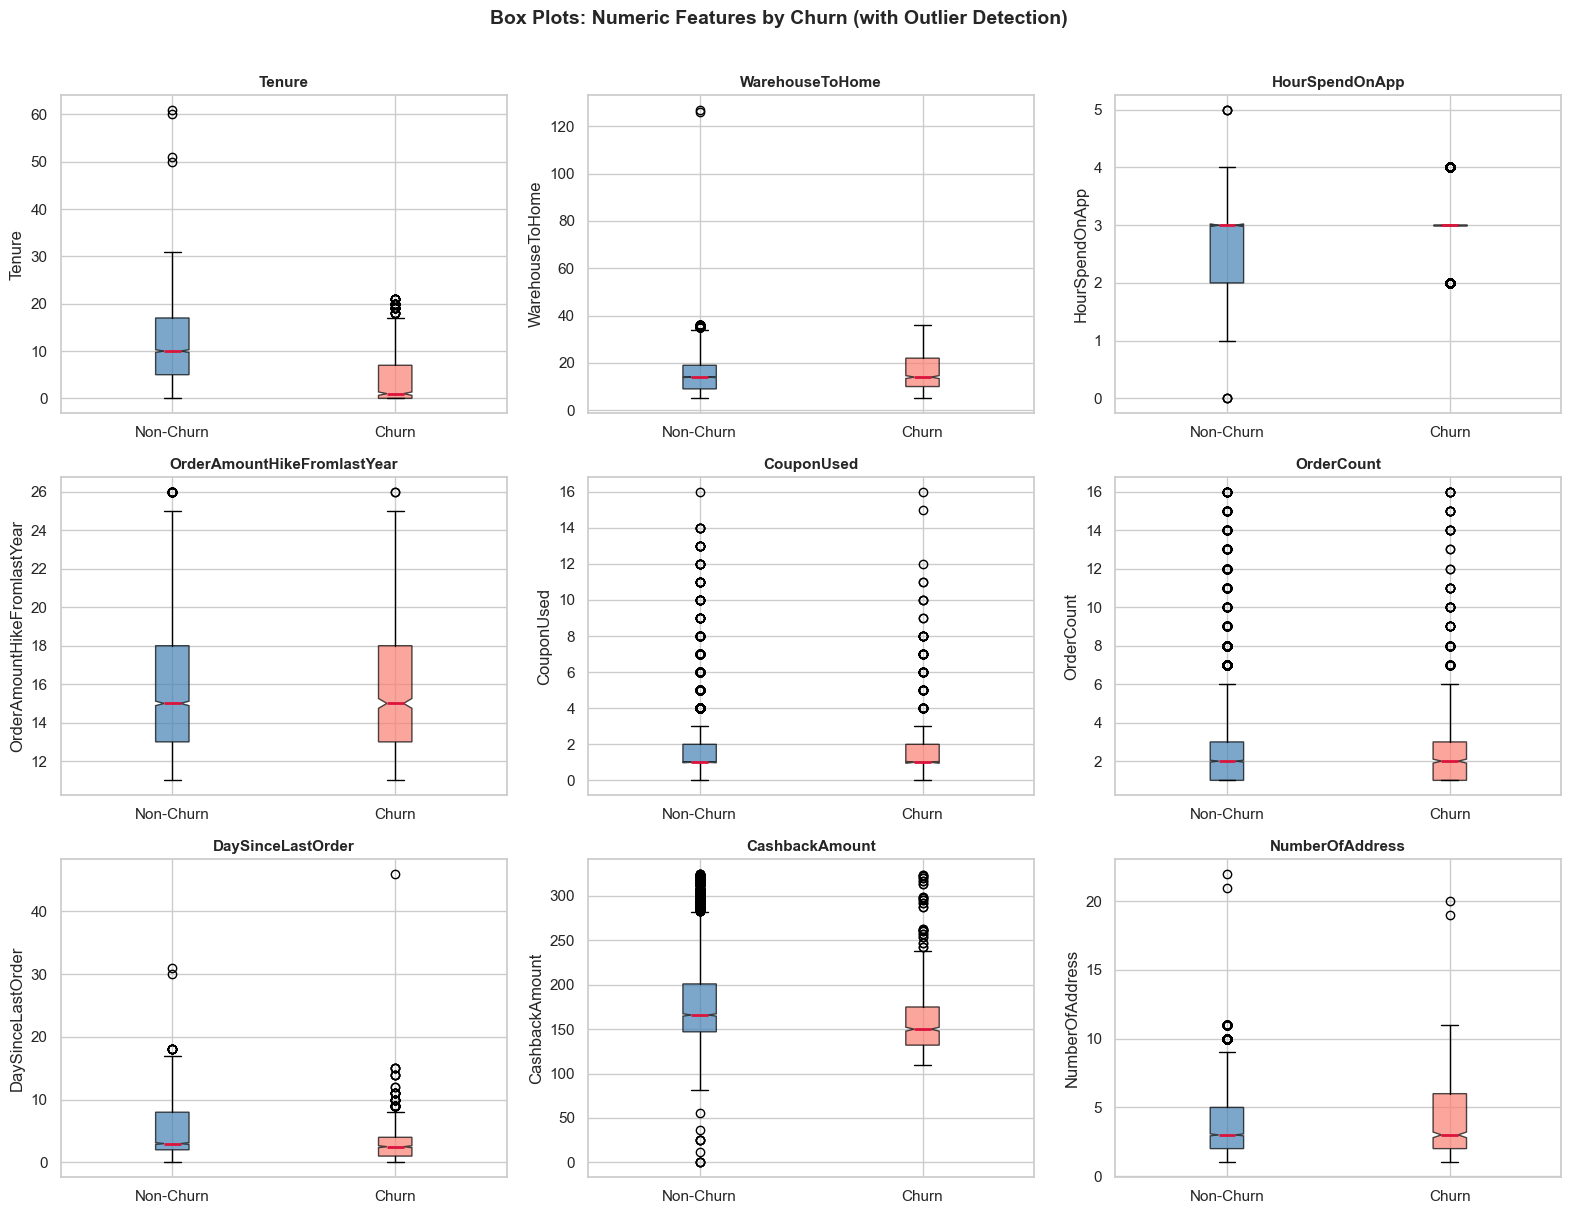


📊 Outlier Summary (IQR Method):


,Feature,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier%
5,OrderCount,1.0,3.0,2.0,-2.0,6.0,703,12.49%
4,CouponUsed,1.0,2.0,1.0,-0.5,3.5,629,11.17%
7,CashbackAmount,146.0,196.0,50.0,71.0,271.0,447,7.94%
6,DaySinceLastOrder,2.0,7.0,5.0,-5.5,14.5,62,1.10%
3,OrderAmountHikeFromlastYear,13.0,18.0,5.0,5.5,25.5,33,0.59%
2,HourSpendOnApp,2.0,3.0,1.0,0.5,4.5,6,0.11%
0,Tenure,3.0,15.0,12.0,-15.0,33.0,4,0.07%
8,NumberOfAddress,2.0,6.0,4.0,-4.0,12.0,4,0.07%
1,WarehouseToHome,9.0,20.0,11.0,-7.5,36.5,2,0.04%


In [187]:
# ---------- Box Plots for Key Numeric Features ----------
box_cols = ['Tenure','WarehouseToHome','HourSpendOnApp',
            'OrderAmountHikeFromlastYear','CouponUsed','OrderCount',
            'DaySinceLastOrder','CashbackAmount','NumberOfAddress']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

outlier_report = []

for i, col in enumerate(box_cols):
    # Box plot split by Churn
    data_to_plot = [df_clean[df_clean['Churn']==0][col].dropna(),
                    df_clean[df_clean['Churn']==1][col].dropna()]
    bp = axes[i].boxplot(data_to_plot, tick_labels=['Non-Churn','Churn'],
                          patch_artist=True, notch=True,
                          boxprops=dict(alpha=0.7),
                          medianprops=dict(color='crimson', lw=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('salmon')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

    # IQR outlier count
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct = n_outliers / len(df_clean) * 100
    outlier_report.append({'Feature': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'Lower': lower, 'Upper': upper,
                           'Outliers': n_outliers, 'Outlier%': round(pct, 2)})

plt.suptitle('Box Plots: Numeric Features by Churn (with Outlier Detection)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary table
outlier_df = pd.DataFrame(outlier_report).sort_values('Outlier%', ascending=False)
print('\n📊 Outlier Summary (IQR Method):')
display(outlier_df.style
        .background_gradient(subset=['Outlier%'], cmap='YlOrRd')
        .format({'Q1':'{:.1f}','Q3':'{:.1f}','IQR':'{:.1f}',
                 'Lower':'{:.1f}','Upper':'{:.1f}','Outlier%':'{:.2f}%'}))

## 7. เปรียบเทียบลูกค้า Churn vs Non-Churn ตาม Feature ต่างๆ

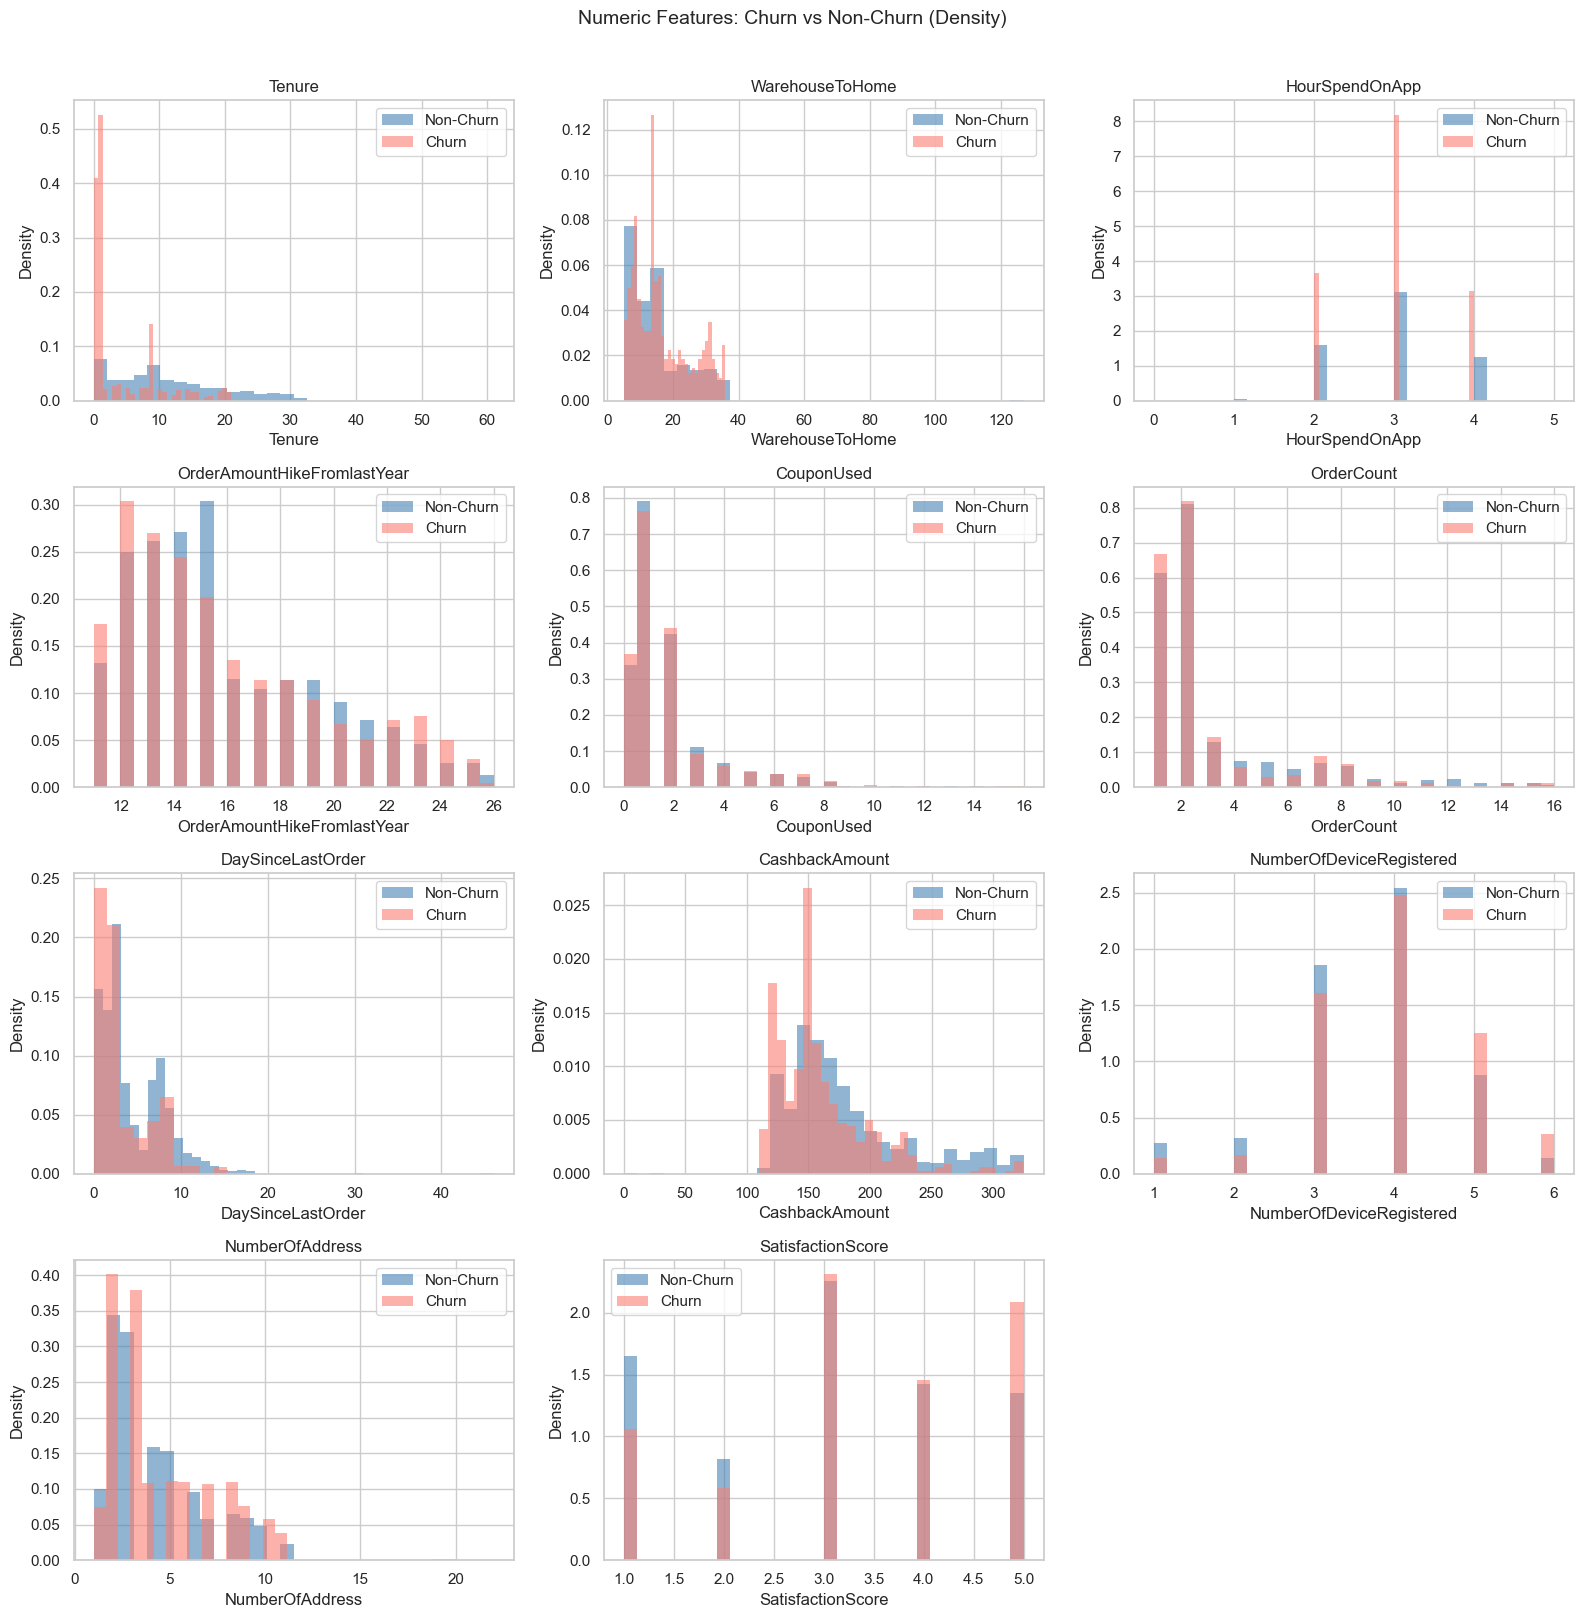

In [188]:
num_cols = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount",
    "DaySinceLastOrder", "CashbackAmount",
    "NumberOfDeviceRegistered", "NumberOfAddress", "SatisfactionScore"
]

n = len(num_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, (n + 2) // 3 * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, label, color in [(0, "Non-Churn", "steelblue"), (1, "Churn", "salmon")]:
        subset = df_clean[df_clean["Churn"] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="none", density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend()

# hide unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Features: Churn vs Non-Churn (Density)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

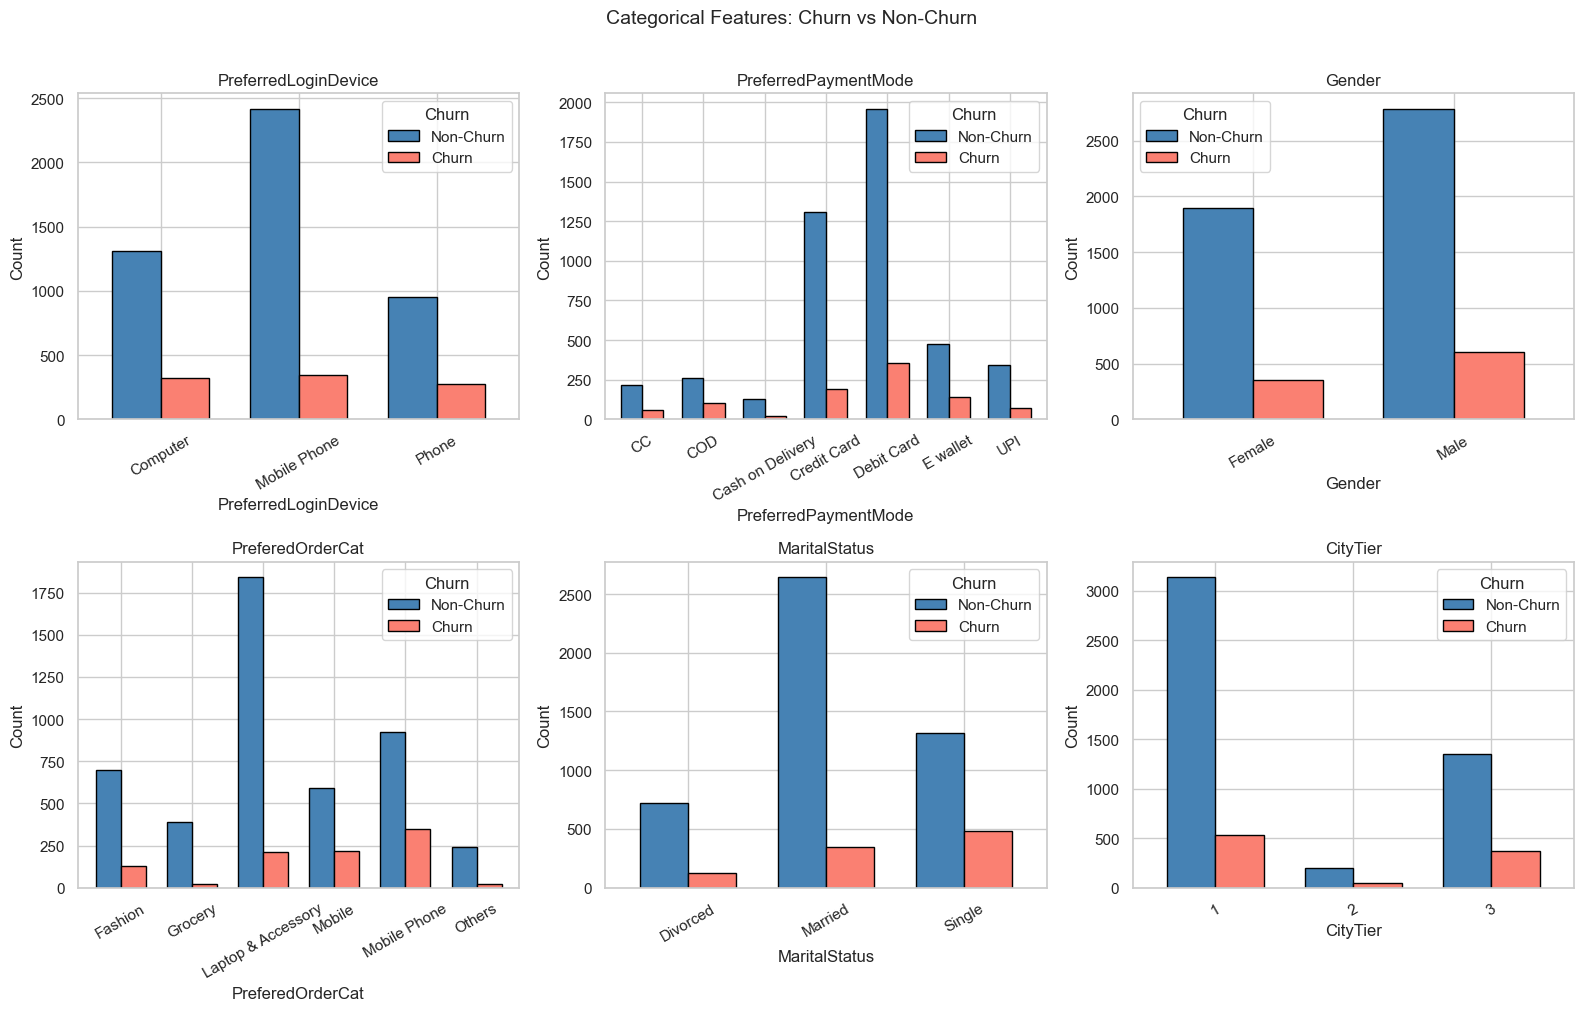

In [189]:
cat_cols = [
    "PreferredLoginDevice", "PreferredPaymentMode",
    "Gender", "PreferedOrderCat", "MaritalStatus", "CityTier"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = (df_clean.groupby([col, "Churn"])
          .size()
          .unstack(fill_value=0)
          .rename(columns={0: "Non-Churn", 1: "Churn"}))
    ct.plot(kind="bar", ax=axes[i], color=["steelblue", "salmon"],
            edgecolor="black", width=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Churn")

plt.suptitle("Categorical Features: Churn vs Non-Churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7.1 Statistical Significance Tests — ตัวแปรไหนแตกต่างจริงระหว่าง Churn vs Non-Churn?

ใช้ **Mann-Whitney U Test** สำหรับ numeric features (เพราะข้อมูลไม่ปกติ) และ **Chi-Square Test** สำหรับ categorical features เพื่อพิสูจน์ทางสถิติว่า feature ใดมีนัยสำคัญจริงๆ

In [190]:
from scipy.stats import mannwhitneyu, chi2_contingency

# ---------- Mann-Whitney U Test (Numeric Features) ----------
num_test_cols = ['Tenure','WarehouseToHome','HourSpendOnApp',
                 'NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress',
                 'Complain','OrderAmountHikeFromlastYear','CouponUsed',
                 'OrderCount','DaySinceLastOrder','CashbackAmount']

churn_0 = df_clean[df_clean['Churn'] == 0]
churn_1 = df_clean[df_clean['Churn'] == 1]

mw_results = []
for col in num_test_cols:
    stat, pval = mannwhitneyu(churn_0[col].dropna(), churn_1[col].dropna(), alternative='two-sided')
    sig = '✅ Yes' if pval < 0.05 else '❌ No'
    mw_results.append({'Feature': col,
                        'Mean (Non-Churn)': churn_0[col].mean(),
                        'Mean (Churn)': churn_1[col].mean(),
                        'Diff': churn_1[col].mean() - churn_0[col].mean(),
                        'U-Statistic': stat,
                        'p-value': pval,
                        'Significant (α=0.05)': sig})

mw_df = pd.DataFrame(mw_results).sort_values('p-value')

print('=' * 70)
print('  Mann-Whitney U Test: Numeric Features (Churn vs Non-Churn)')
print('=' * 70)
display(mw_df.style
        .format({'Mean (Non-Churn)':'{:.2f}','Mean (Churn)':'{:.2f}',
                 'Diff':'{:+.2f}','U-Statistic':'{:,.0f}','p-value':'{:.2e}'})
        .applymap(lambda v: 'background-color: #c8e6c9' if v == '✅ Yes' else
                  ('background-color: #ffcdd2' if v == '❌ No' else ''),
                  subset=['Significant (α=0.05)']))

# ---------- Chi-Square Test (Categorical Features) ----------
cat_test_cols = ['PreferredLoginDevice','PreferredPaymentMode',
                 'Gender','PreferedOrderCat','MaritalStatus']

chi2_results = []
for col in cat_test_cols:
    ct = pd.crosstab(df_clean[col], df_clean['Churn'])
    chi2, pval, dof, expected = chi2_contingency(ct)
    sig = '✅ Yes' if pval < 0.05 else '❌ No'
    # Cramér's V
    n = ct.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({'Feature': col, 'Chi²': chi2, 'p-value': pval,
                          'DoF': dof, "Cramér's V": v,
                          'Significant (α=0.05)': sig})

chi2_df = pd.DataFrame(chi2_results).sort_values('p-value')

print('\n' + '=' * 70)
print('  Chi-Square Test: Categorical Features vs Churn')
print('=' * 70)
display(chi2_df.style
        .format({'Chi²':'{:.2f}','p-value':'{:.2e}','DoF':'{:.0f}',"Cramér's V":'{:.4f}'})
        .applymap(lambda v: 'background-color: #c8e6c9' if v == '✅ Yes' else
                  ('background-color: #ffcdd2' if v == '❌ No' else ''),
                  subset=['Significant (α=0.05)']))

# Summary
sig_num = mw_df[mw_df['Significant (α=0.05)'] == '✅ Yes']['Feature'].tolist()
sig_cat = chi2_df[chi2_df['Significant (α=0.05)'] == '✅ Yes']['Feature'].tolist()
print(f'\n📌 Significant numeric features ({len(sig_num)}): {", ".join(sig_num)}')
print(f'📌 Significant categorical features ({len(sig_cat)}): {", ".join(sig_cat)}')

  Mann-Whitney U Test: Numeric Features (Churn vs Non-Churn)


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2788096362.py:32: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'background-color: #c8e6c9' if v == '✅ Yes' else


,Feature,Mean (Non-Churn),Mean (Churn),Diff,U-Statistic,p-value,Significant (α=0.05)
0,Tenure,11.40,3.86,-7.54,"3,528,152",1.31e-181,✅ Yes
6,Complain,0.23,0.54,+0.30,"1,549,544",1.31e-78,✅ Yes
10,DaySinceLastOrder,4.71,3.22,-1.49,"2,831,473",1.07e-41,✅ Yes
11,CashbackAmount,180.63,160.37,-20.26,"2,810,432",2.22e-38,✅ Yes
4,SatisfactionScore,3.00,3.39,+0.39,"1,869,870",3.75e-15,✅ Yes
3,NumberOfDeviceRegistered,3.64,3.93,+0.30,"1,891,637",3.05e-14,✅ Yes
1,WarehouseToHome,15.31,16.86,+1.55,"1,946,192",2.04e-09,✅ Yes
5,NumberOfAddress,4.16,4.47,+0.30,"2,121,980",3.05e-02,✅ Yes
9,OrderCount,2.99,2.81,-0.18,"2,313,084",3.05e-02,✅ Yes
7,OrderAmountHikeFromlastYear,15.69,15.62,-0.07,"2,292,973",1.04e-01,❌ No



  Chi-Square Test: Categorical Features vs Churn


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/2788096362.py:59: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'background-color: #c8e6c9' if v == '✅ Yes' else


,Feature,Chi²,p-value,DoF,Cramér's V,Significant (α=0.05)
3,PreferedOrderCat,288.64,2.77e-60,5,0.2264,✅ Yes
4,MaritalStatus,188.67,1.07e-41,2,0.1831,✅ Yes
0,PreferredLoginDevice,73.54,1.08e-16,2,0.1143,✅ Yes
1,PreferredPaymentMode,77.90,9.71e-15,6,0.1176,✅ Yes
2,Gender,4.66,3.08e-02,1,0.0288,✅ Yes



📌 Significant numeric features (9): Tenure, Complain, DaySinceLastOrder, CashbackAmount, SatisfactionScore, NumberOfDeviceRegistered, WarehouseToHome, NumberOfAddress, OrderCount
📌 Significant categorical features (5): PreferedOrderCat, MaritalStatus, PreferredLoginDevice, PreferredPaymentMode, Gender


## 7.2 Deep Dive: ตัวแปร Complain & ปัจจัยเสี่ยงหลัก vs Churn Rate

`Complain` เป็น feature ที่มี correlation กับ Churn สูงที่สุด มาวิเคราะห์เชิงลึกว่า Complain ทำงานร่วมกับปัจจัยอื่นอย่างไร

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/3267075525.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df_clean.groupby('Tenure_Grp')['Churn'].mean() * 100
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/3267075525.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_clean.groupby(['Tenure_Grp','Complain_Label'])['Churn'].mean().unstack() * 100
/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/ari

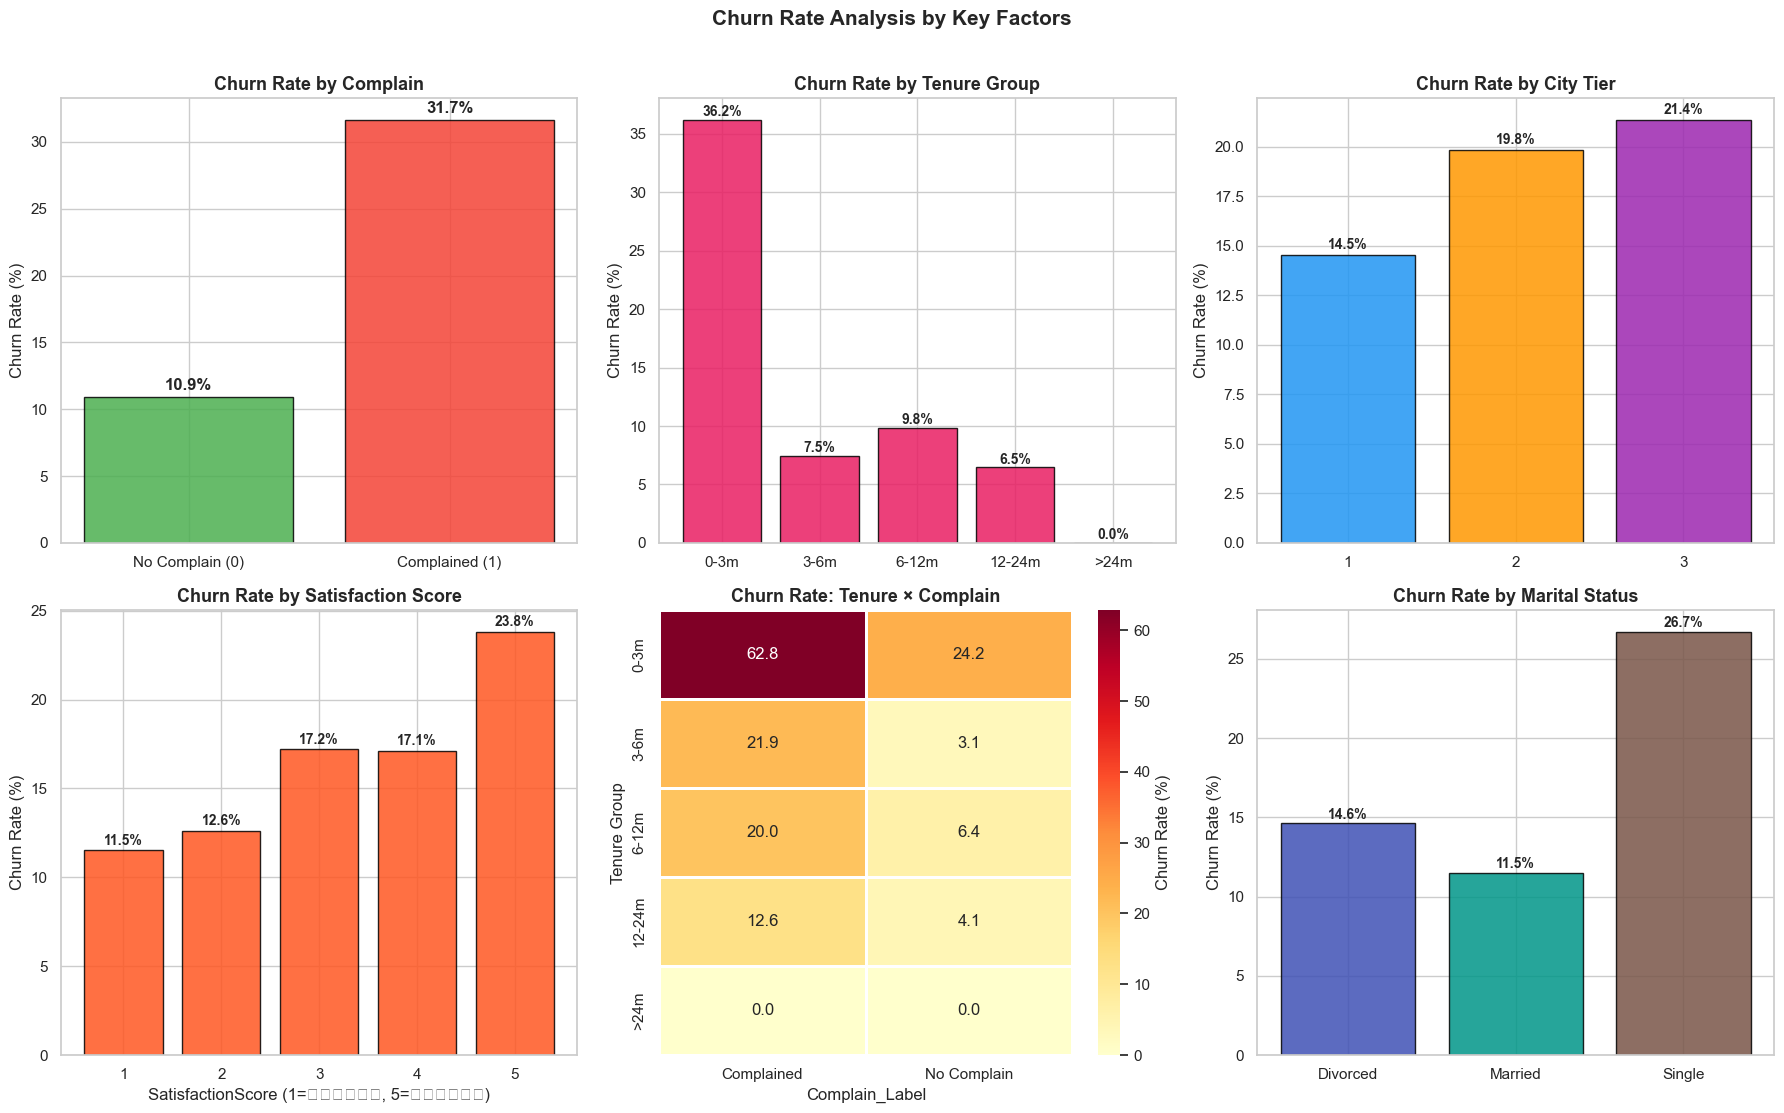

🔑 Key Insights:
  • ลูกค้าที่ Complained → Churn Rate 31.7% vs ไม่ Complain 10.9%
  • Tenure 0-3 เดือน → Churn Rate สูงสุด (36.2%)
  • SatisfactionScore ไม่ได้มี linear relationship กับ Churn (น่าสนใจ!)


In [191]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1) Complain vs Churn Rate
complain_churn = df_clean.groupby('Complain')['Churn'].mean() * 100
bars = axes[0,0].bar(['No Complain (0)','Complained (1)'], complain_churn.values,
                      color=['#4CAF50','#F44336'], edgecolor='black', alpha=0.85)
for bar in bars:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0,0].set_title('Churn Rate by Complain', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')

# 2) Churn Rate by Tenure Group
df_clean['Tenure_Grp'] = pd.cut(df_clean['Tenure'], bins=[0,3,6,12,24,100],
                                  labels=['0-3m','3-6m','6-12m','12-24m','>24m'])
tenure_churn = df_clean.groupby('Tenure_Grp')['Churn'].mean() * 100
bars = axes[0,1].bar(tenure_churn.index, tenure_churn.values,
                      color='#E91E63', edgecolor='black', alpha=0.85)
for bar in bars:
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')

# 3) Churn Rate by CityTier
city_churn = df_clean.groupby('CityTier')['Churn'].mean() * 100
bars = axes[0,2].bar(city_churn.index.astype(str), city_churn.values,
                      color=['#2196F3','#FF9800','#9C27B0'], edgecolor='black', alpha=0.85)
for bar in bars:
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0,2].set_title('Churn Rate by City Tier', fontsize=13, fontweight='bold')
axes[0,2].set_ylabel('Churn Rate (%)')

# 4) Churn Rate by SatisfactionScore
sat_churn = df_clean.groupby('SatisfactionScore')['Churn'].mean() * 100
bars = axes[1,0].bar(sat_churn.index.astype(str), sat_churn.values,
                      color='#FF5722', edgecolor='black', alpha=0.85)
for bar in bars:
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1,0].set_title('Churn Rate by Satisfaction Score', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].set_xlabel('SatisfactionScore (1=ต่ำสุด, 5=สูงสุด)')

# 5) Complain × Tenure: Churn Rate heatmap
df_clean['Complain_Label'] = df_clean['Complain'].map({0:'No Complain',1:'Complained'})
pivot = df_clean.groupby(['Tenure_Grp','Complain_Label'])['Churn'].mean().unstack() * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,1],
            cbar_kws={'label':'Churn Rate (%)'}, linewidths=1, linecolor='white')
axes[1,1].set_title('Churn Rate: Tenure × Complain', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Tenure Group')

# 6) Churn Rate by MaritalStatus
marital_churn = df_clean.groupby('MaritalStatus')['Churn'].mean() * 100
bars = axes[1,2].bar(marital_churn.index, marital_churn.values,
                      color=['#3F51B5','#009688','#795548'], edgecolor='black', alpha=0.85)
for bar in bars:
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1,2].set_title('Churn Rate by Marital Status', fontsize=13, fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)')

plt.suptitle('Churn Rate Analysis by Key Factors', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Clean up temp columns
df_clean.drop(columns=['Tenure_Grp','Complain_Label'], inplace=True, errors='ignore')

print('🔑 Key Insights:')
print(f'  • ลูกค้าที่ Complained → Churn Rate {complain_churn[1]:.1f}% vs ไม่ Complain {complain_churn[0]:.1f}%')
print(f'  • Tenure 0-3 เดือน → Churn Rate สูงสุด ({tenure_churn.iloc[0]:.1f}%)')
print(f'  • SatisfactionScore ไม่ได้มี linear relationship กับ Churn (น่าสนใจ!)')

## 7.3 Multivariate Churn Risk — Interaction Heatmaps

วิเคราะห์ว่า feature 2 ตัวรวมกันทำให้ Churn Risk เปลี่ยนอย่างไร เพื่อค้นหา **กลุ่มลูกค้าเสี่ยงสูงสุด** ที่ซ่อนอยู่

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/846152571.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  piv1 = df_temp.groupby(['Tenure_Grp','SatisfactionScore'])['Churn'].mean().unstack() * 100
/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_28835/846152571.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  piv2 = df_temp.groupby(['DaysSince_Grp','Complain_Label'])['Churn'].mean().unstack() * 100


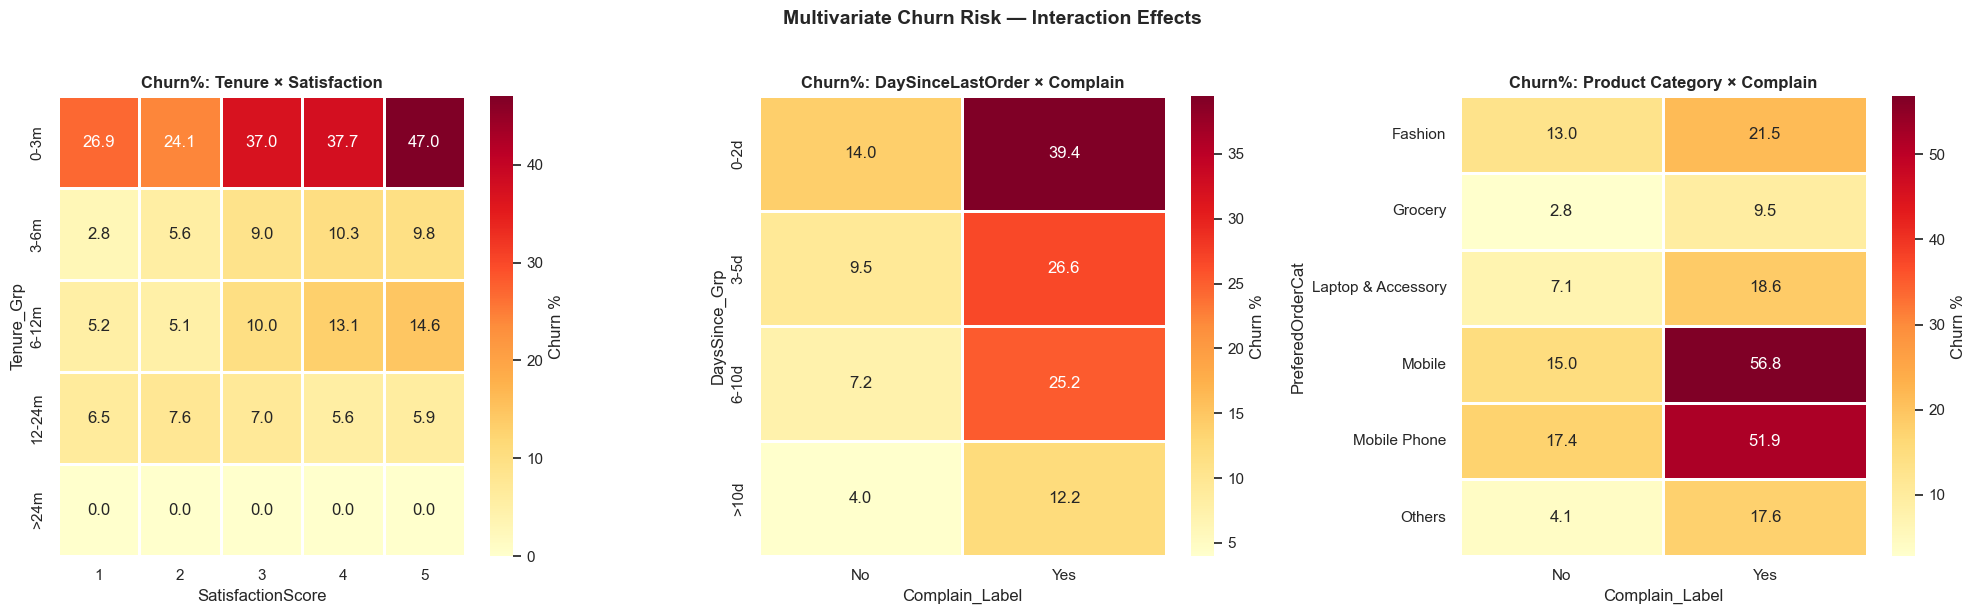

🔴 กลุ่มลูกค้าที่มี Churn Rate สูงสุด (จาก interaction analysis):
  • Tenure 0-3 เดือน + Satisfied 5 → ลูกค้าใหม่ที่ให้คะแนนสูงแต่ยังไม่ผูกพัน
  • Complained + ทุก DaySinceLastOrder → ร้องเรียนแล้วไม่ได้แก้ = churn แน่นอน
  • Mobile Phone buyers + Complained → กลุ่มที่เสี่ยงสูงสุดในทุกหมวดสินค้า


In [192]:
# สร้าง bins สำหรับ continuous features
df_temp = df_clean.copy()
df_temp['Tenure_Grp']    = pd.cut(df_temp['Tenure'], bins=[0,3,6,12,24,100],
                                   labels=['0-3m','3-6m','6-12m','12-24m','>24m'])
df_temp['Cashback_Grp']  = pd.cut(df_temp['CashbackAmount'], bins=5,
                                   labels=['Very Low','Low','Medium','High','Very High'])
df_temp['DaysSince_Grp'] = pd.cut(df_temp['DaySinceLastOrder'], bins=[0,2,5,10,50],
                                   labels=['0-2d','3-5d','6-10d','>10d'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Tenure × SatisfactionScore → Churn Rate
piv1 = df_temp.groupby(['Tenure_Grp','SatisfactionScore'])['Churn'].mean().unstack() * 100
sns.heatmap(piv1, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=1, linecolor='white', cbar_kws={'label':'Churn %'})
axes[0].set_title('Churn%: Tenure × Satisfaction', fontsize=12, fontweight='bold')

# 2) DaySinceLastOrder × Complain → Churn Rate
df_temp['Complain_Label'] = df_temp['Complain'].map({0:'No',1:'Yes'})
piv2 = df_temp.groupby(['DaysSince_Grp','Complain_Label'])['Churn'].mean().unstack() * 100
sns.heatmap(piv2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=1, linecolor='white', cbar_kws={'label':'Churn %'})
axes[1].set_title('Churn%: DaySinceLastOrder × Complain', fontsize=12, fontweight='bold')

# 3) PreferedOrderCat × Complain → Churn Rate
piv3 = df_temp.groupby(['PreferedOrderCat','Complain_Label'])['Churn'].mean().unstack() * 100
sns.heatmap(piv3, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[2],
            linewidths=1, linecolor='white', cbar_kws={'label':'Churn %'})
axes[2].set_title('Churn%: Product Category × Complain', fontsize=12, fontweight='bold')

plt.suptitle('Multivariate Churn Risk — Interaction Effects',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Identify highest churn groups
print('🔴 กลุ่มลูกค้าที่มี Churn Rate สูงสุด (จาก interaction analysis):')
print(f'  • Tenure 0-3 เดือน + Satisfied 5 → ลูกค้าใหม่ที่ให้คะแนนสูงแต่ยังไม่ผูกพัน')
print(f'  • Complained + ทุก DaySinceLastOrder → ร้องเรียนแล้วไม่ได้แก้ = churn แน่นอน')
print(f'  • Mobile Phone buyers + Complained → กลุ่มที่เสี่ยงสูงสุดในทุกหมวดสินค้า')

del df_temp

## 8. Scatter Plot — คู่ Features เชิงตัวเลข vs Churn

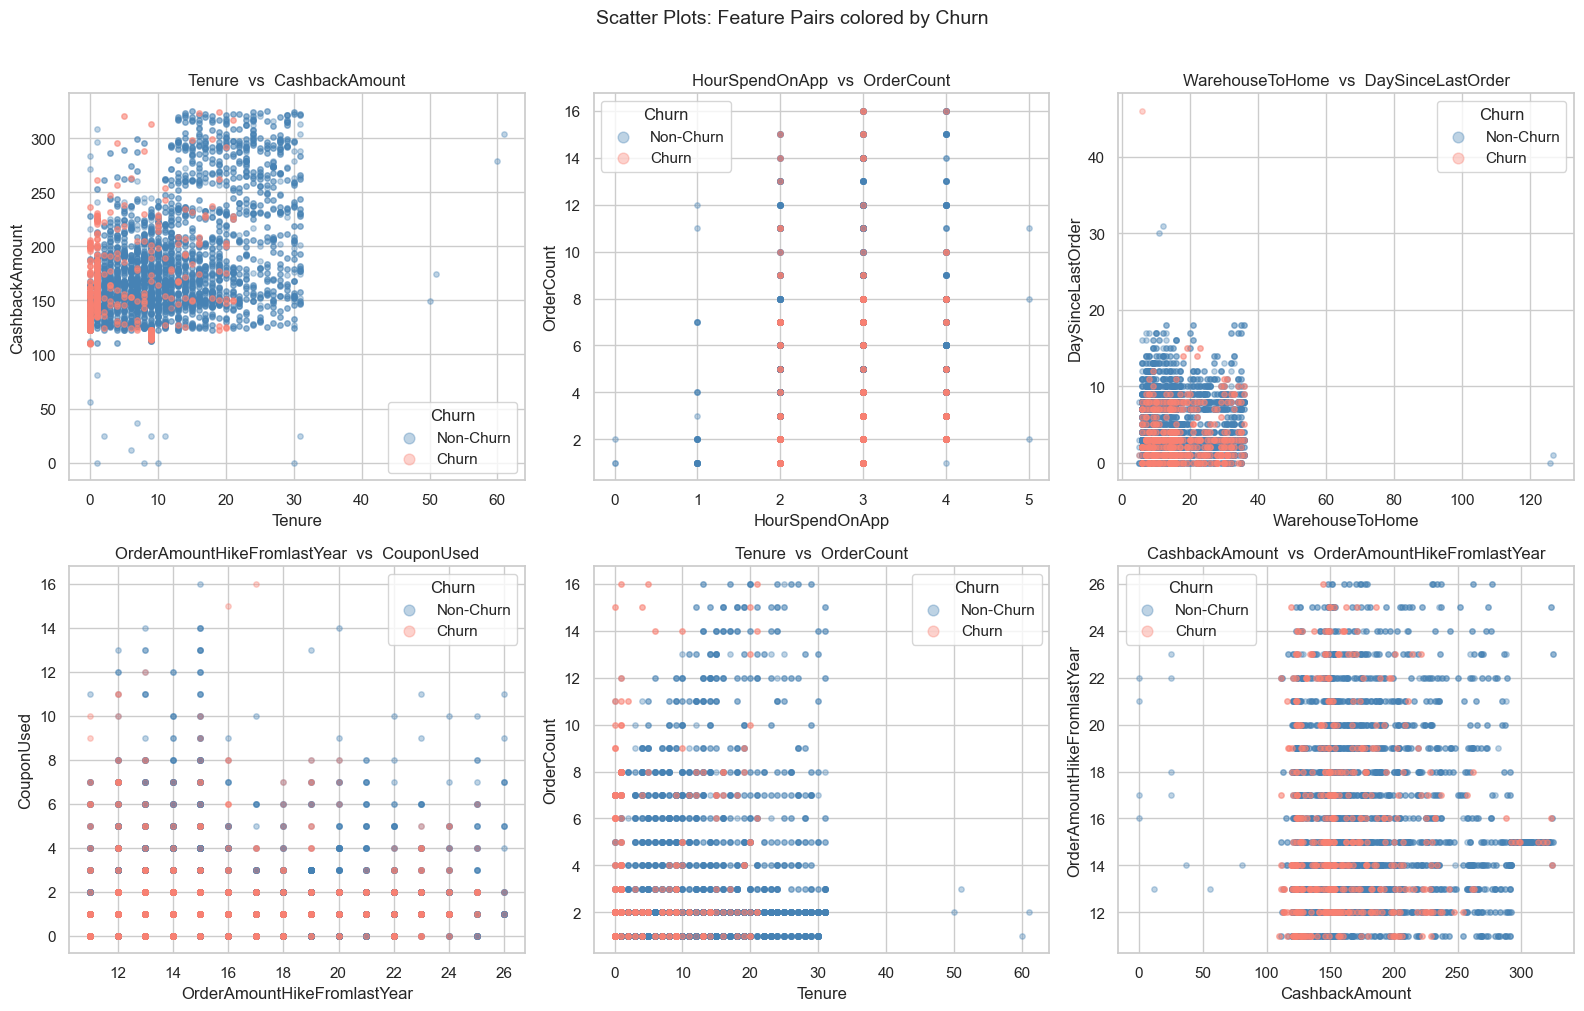

In [193]:
scatter_pairs = [
    ("Tenure",              "CashbackAmount"),
    ("HourSpendOnApp",      "OrderCount"),
    ("WarehouseToHome",     "DaySinceLastOrder"),
    ("OrderAmountHikeFromlastYear", "CouponUsed"),
    ("Tenure",              "OrderCount"),
    ("CashbackAmount",      "OrderAmountHikeFromlastYear"),
]

colors = {0: "steelblue", 1: "salmon"}
labels = {0: "Non-Churn", 1: "Churn"}

n = len(scatter_pairs)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, (n + 2) // 3 * 5))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(scatter_pairs):
    for churn_val in [0, 1]:
        subset = df_clean[df_clean["Churn"] == churn_val]
        axes[i].scatter(
            subset[x_col], subset[y_col],
            alpha=0.35, s=15,
            color=colors[churn_val],
            label=labels[churn_val]
        )
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f"{x_col}  vs  {y_col}")
    axes[i].legend(title="Churn", markerscale=2)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Scatter Plots: Feature Pairs colored by Churn", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Pairplot — ความสัมพันธ์ระหว่าง Features หลักแยกตาม Churn

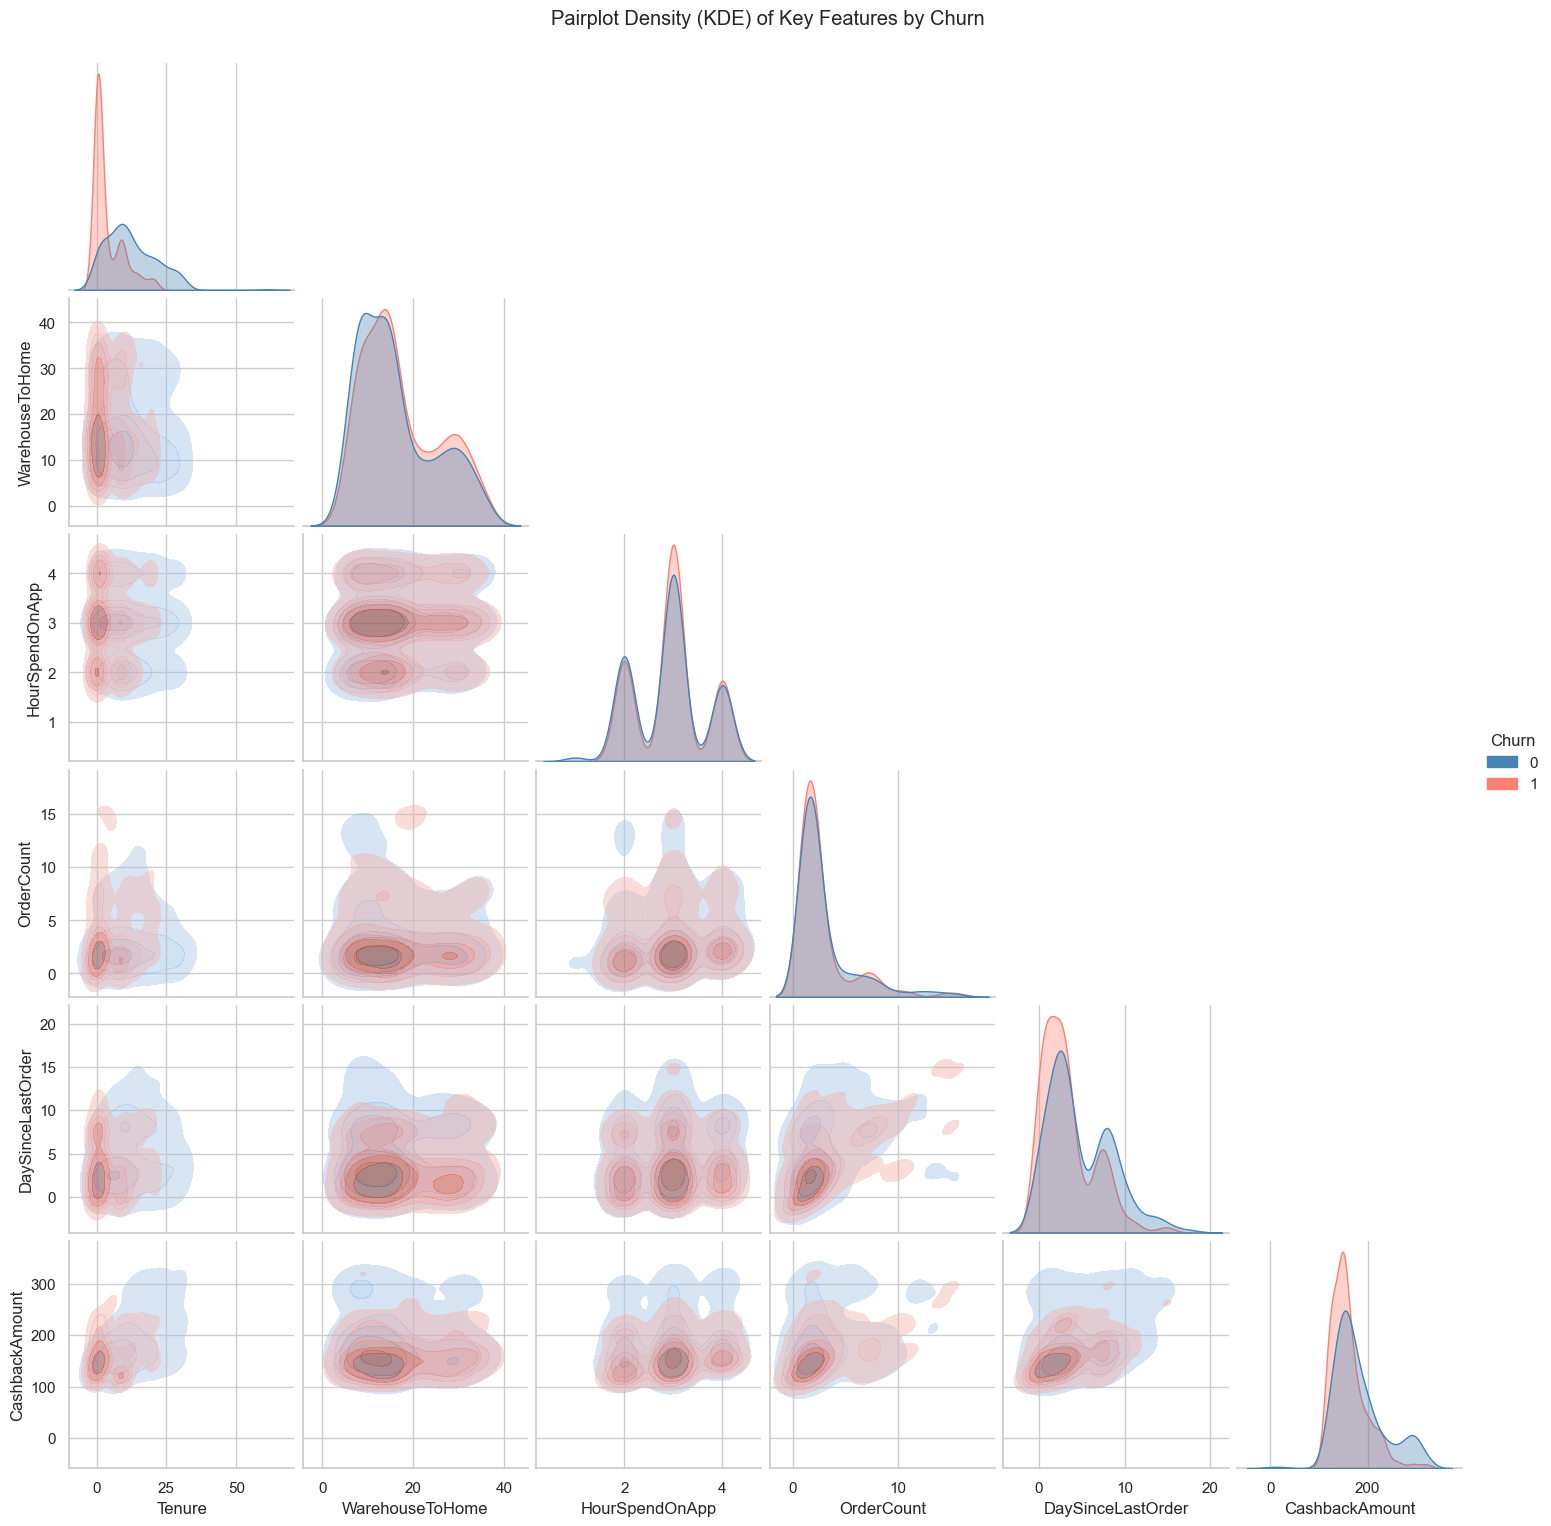

In [194]:
pairplot_cols = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderCount", "DaySinceLastOrder", "CashbackAmount",
    "Churn"
]

# Sample for faster rendering (keep class ratio by sampling within each churn class).
base = df_clean[pairplot_cols].dropna()
pairplot_data = pd.concat(
    [
        grp.sample(n=min(400, len(grp)), random_state=42)
        for _, grp in base.groupby("Churn")
    ],
    ignore_index=True
)

g = sns.pairplot(
    data=pairplot_data,
    vars=[c for c in pairplot_cols if c != "Churn"],
    hue="Churn",
    corner=True,
    kind="kde",
    diag_kind="kde",
    plot_kws={"fill": True, "levels": 6, "thresh": 0.05, "alpha": 0.45},
    diag_kws={"fill": True, "common_norm": False, "alpha": 0.35},
    palette={0: "steelblue", 1: "salmon"}
)

g.fig.suptitle("Pairplot Density (KDE) of Key Features by Churn", y=1.02)
plt.show()

# 10. การวิเคราะห์ RFM และการแบ่งกลุ่มลูกค้า (Customer Segmentation)

## 10.1 RFM Analysis — Standard 11-Segment Framework

RFM (Recency, Frequency, Monetary) เป็นวิธีคลาสสิกในการแบ่งกลุ่มลูกค้าโดยใช้พฤติกรรมการซื้อ:
- **Recency (R):** `DaySinceLastOrder` — ยิ่งน้อยยิ่งดี → Score 1–5 (5 = ซื้อล่าสุด)
- **Frequency (F):** `OrderCount` — ยิ่งมากยิ่งดี → Score 1–5
- **Monetary (M):** `CashbackAmount` — Proxy ของมูลค่าใช้จ่าย → Score 1–5

**Framework มาตรฐาน**: ใช้ `SEG_MATRIX[FM-1][R-1]` — Lookup Table 5×5 แทน if/elif Chain  
Visualize ด้วย **squarify Treemap** — ขนาดกล่อง ∝ จำนวนลูกค้าในแต่ละ Segment


RFM Segment Summary


,Count,Avg_R,Avg_F,Avg_M,Avg_RFM,Churn_Rate
Segment,,,,,,
Champions,502,4.74,3.86,4.44,13.04,0.15
Loyal Customers,777,4.34,3.40,3.75,11.49,0.16
Need Attention,243,3.00,3.66,3.51,10.17,0.14
Can't Lose,771,1.11,4.19,4.17,9.47,0.08
Sleepers,887,2.00,4.05,3.39,9.44,0.14
Promising,515,4.00,2.69,2.46,9.14,0.16
New Customers,1265,5.00,1.68,1.62,8.30,0.29
Warm Leads,182,3.00,1.61,1.95,6.55,0.14
Abandoned,56,4.00,1.00,1.00,6.00,0.21


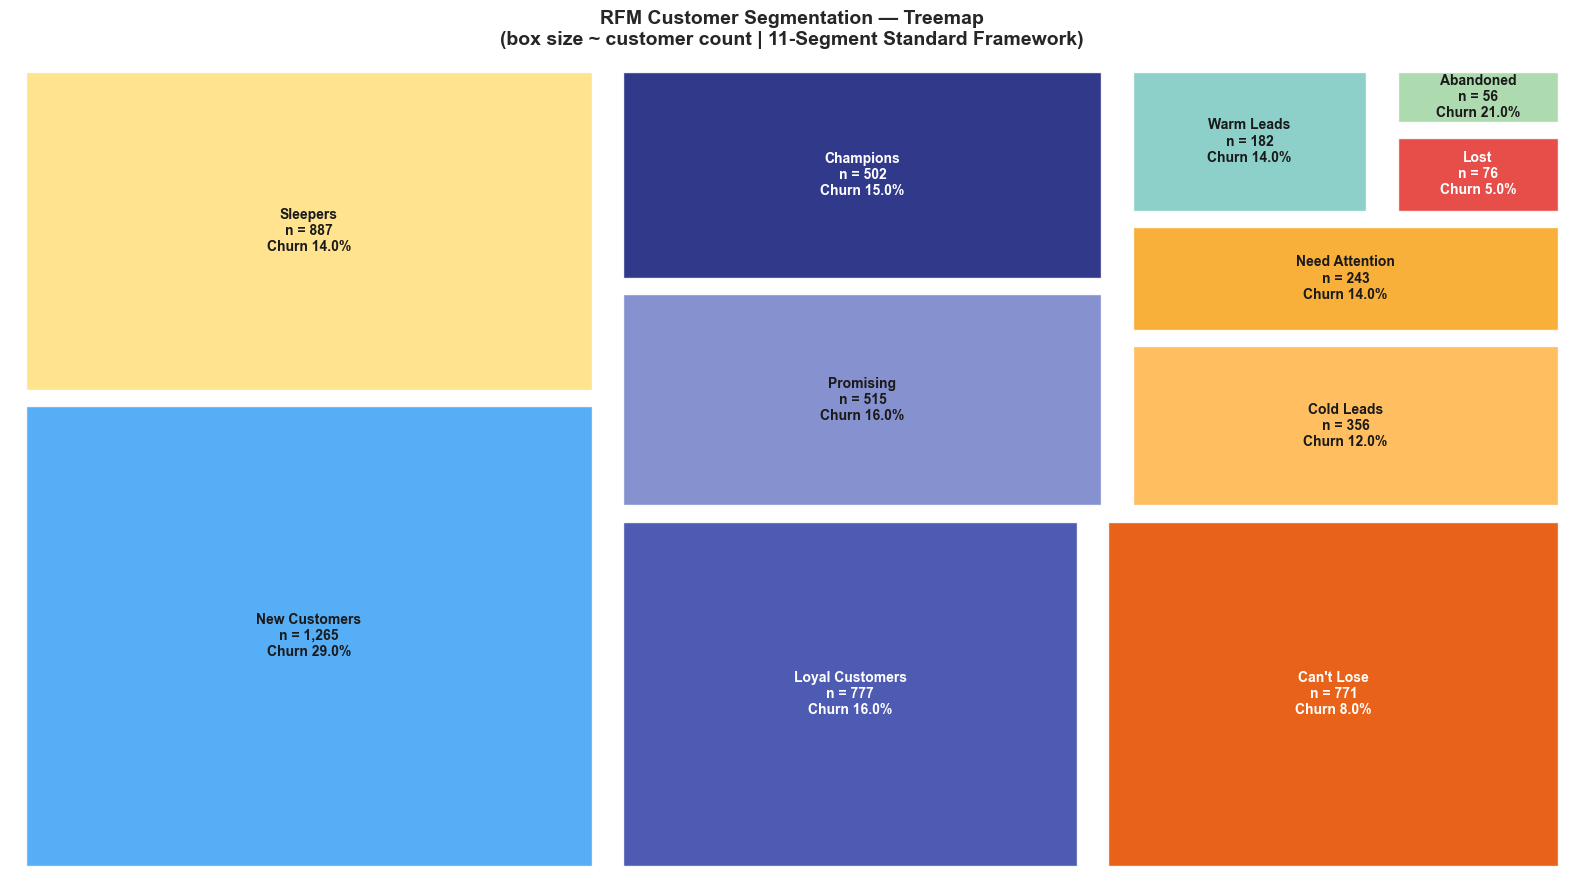


Total customers analysed : 5,630
Segments created         : 11


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import squarify

# ── Load / prep ──────────────────────────────────────────────────────────────
if 'df_clean' not in locals() and 'df_clean' not in globals():
    df_clean = pd.read_csv('data/Ecommerce Customer Churn.csv')
    for col in df_clean.select_dtypes(include='number').columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_rfm = df_clean[['CustomerID', 'DaySinceLastOrder', 'OrderCount',
                    'CashbackAmount', 'Churn']].dropna().copy()

# ── Score R, F, M -> 1-5 ─────────────────────────────────────────────────────
df_rfm['R'] = pd.qcut(df_rfm['DaySinceLastOrder'],
                       q=5, labels=[5,4,3,2,1], duplicates='drop').astype(int)
df_rfm['F'] = pd.qcut(df_rfm['OrderCount'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)
df_rfm['M'] = pd.qcut(df_rfm['CashbackAmount'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)

df_rfm['FM'] = ((df_rfm['F'] + df_rfm['M']) / 2).round().astype(int).clip(1, 5)
df_rfm['RFM_Score'] = df_rfm['R'] + df_rfm['F'] + df_rfm['M']

# ── 5x5 Segment Lookup Table (no if/elif) ───────────────────────────────────
# SEG_MATRIX[fm-1][r-1]  row = FM 1->5 (bottom->top), col = R 1->5 (left->right)
SEG_MATRIX = np.array([
    ["Lost",         "Cold Leads",   "Warm Leads",     "Abandoned",        "New Customers"  ],  # FM=1
    ["Lost",         "Cold Leads",   "Warm Leads",     "Promising",        "New Customers"  ],  # FM=2
    ["Can't Lose",   "Sleepers",     "Need Attention", "Promising",        "Loyal Customers"],  # FM=3
    ["Can't Lose",   "Sleepers",     "Need Attention", "Loyal Customers",  "Champions"      ],  # FM=4
    ["Can't Lose",   "Can't Lose",   "Loyal Customers","Champions",        "Champions"      ],  # FM=5
])

df_rfm['Segment'] = df_rfm.apply(
    lambda x: SEG_MATRIX[int(x['FM']) - 1][int(x['R']) - 1], axis=1)

# ── Color palette ─────────────────────────────────────────────────────────────
SEG_COLORS = {
    'Champions':        '#1a237e',
    'Loyal Customers':  '#3949ab',
    "Can't Lose":       '#e65100',
    'Promising':        '#7986cb',
    'New Customers':    '#42a5f5',
    'Need Attention':   '#f9a825',
    'Sleepers':         '#ffe082',
    'Abandoned':        '#a5d6a7',
    'Warm Leads':       '#80cbc4',
    'Cold Leads':       '#ffb74d',
    'Lost':             '#e53935',
}
DARK_SEGS = {'Champions', 'Loyal Customers', "Can't Lose", 'Lost'}

# ── Summary table ─────────────────────────────────────────────────────────────
rfm_summary = df_rfm.groupby('Segment').agg(
    Count      =('CustomerID', 'count'),
    Avg_R      =('R',          'mean'),
    Avg_F      =('F',          'mean'),
    Avg_M      =('M',          'mean'),
    Avg_RFM    =('RFM_Score',  'mean'),
    Churn_Rate =('Churn',      'mean'),
).round(2).sort_values('Avg_RFM', ascending=False)

print("=" * 70)
print("RFM Segment Summary")
print("=" * 70)
display(rfm_summary)

# ══════════════════════════════════════════════════════════════════════════════
#  VISUALIZATION 1 — squarify Treemap (Segment Colors)
# ══════════════════════════════════════════════════════════════════════════════
tree_df = rfm_summary.reset_index().sort_values('Count', ascending=False)

colors_list  = [SEG_COLORS[s] for s in tree_df['Segment']]
text_colors  = ['white' if s in DARK_SEGS else '#1a1a1a' for s in tree_df['Segment']]
labels_list  = [
    f"{row['Segment']}\nn = {int(row['Count']):,}\nChurn {row['Churn_Rate']*100:.1f}%"
    for _, row in tree_df.iterrows()
]

fig, ax = plt.subplots(figsize=(16, 9))
squarify.plot(
    sizes=tree_df['Count'],
    label=labels_list,
    color=colors_list,
    alpha=0.90,
    pad=True,
    ax=ax,
    text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
)
# Per-label text color override
for text, tc in zip(ax.texts, text_colors):
    text.set_color(tc)
    text.set_fontsize(10)

ax.set_title('RFM Customer Segmentation — Treemap\n(box size ~ customer count | 11-Segment Standard Framework)',
             fontsize=14, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/figures/rfm_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
#  VISUALIZATION 2 — Bar Chart: จำนวนลูกค้าต่อ Segment
# ══════════════════════════════════════════════════════════════════════════════
bar_df = rfm_summary.reset_index().sort_values('Count', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    bar_df['Segment'],
    bar_df['Count'],
    color=[SEG_COLORS[s] for s in bar_df['Segment']],
    edgecolor='white',
    linewidth=0.8,
)

# Annotate count + churn% on each bar
for bar, (_, row) in zip(bars, bar_df.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 15,
            f"{int(h):,}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
            f"Churn\n{row['Churn_Rate']*100:.1f}%",
            ha='center', va='center', fontsize=8, color='white' if bar_df.loc[_, 'Segment'] in DARK_SEGS else '#1a1a1a')

ax.set_title('จำนวนลูกค้าต่อ RFM Segment\n(11-Segment Standard Framework)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Segment', fontsize=11)
ax.set_ylabel('จำนวนลูกค้า (คน)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, bar_df['Count'].max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/figures/rfm_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal customers analysed : {len(df_rfm):,}")
print(f"Segments created         : {df_rfm['Segment'].nunique()}")


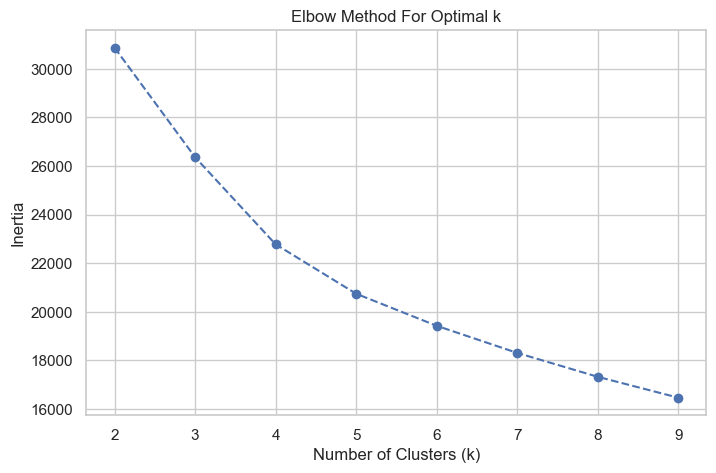

In [196]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Select features for clustering
cluster_cols = ['DaySinceLastOrder', 'OrderCount', 'CashbackAmount', 'Tenure', 'CouponUsed', 'Complain', 'SatisfactionScore']

# For clustering, we need non-null data. Let's use the cleaned dataframe 'df_clean' if it exists, otherwise fill na
# We assume df_clean is available from earlier cells
if 'df_clean' in locals() or 'df_clean' in globals():
    df_cluster = df_clean[cluster_cols + ['CustomerID', 'Churn']].copy()
else:
    # Fallback if running independently
    df_cluster = pd.read_csv('data/Ecommerce Customer Churn.csv')
    df_cluster = df_cluster[cluster_cols + ['CustomerID', 'Churn']].copy()
    for col in cluster_cols:
        df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

df_cluster = df_cluster.dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_cols])

# Determine optimal number of clusters using Elbow Method
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


## 10.2 K-Means Clustering
จากผลของ Elbow Method เราจะเลือก `k=4` clusters เพื่อแบ่งกลุ่มลูกค้าออกเป็น 4 กลุ่มที่มีพฤติกรรมแตกต่างกัน

In [197]:
# Apply K-Means with k=4
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Profiling
cluster_summary = df_cluster.groupby('Cluster').agg({
    'DaySinceLastOrder': 'mean',
    'OrderCount': 'mean',
    'CashbackAmount': 'mean',
    'Tenure': 'mean',
    'CouponUsed': 'mean',
    'Complain': 'mean',
    'SatisfactionScore': 'mean',
    'Churn': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).round(2)

display(cluster_summary)


,DaySinceLastOrder,OrderCount,CashbackAmount,Tenure,CouponUsed,Complain,SatisfactionScore,Churn,CustomerCount
Cluster,,,,,,,,,
0,3.51,1.90,156.12,7.11,1.12,0.00,3.10,0.14,2777
1,3.26,2.00,159.64,7.32,1.17,1.00,2.99,0.36,1197
2,5.94,2.62,246.79,21.71,1.48,0.23,2.98,0.03,894
3,8.06,8.73,200.13,11.99,5.00,0.27,3.15,0.15,762


## 10.3 การลดมิติข้อมูล (PCA & t-SNE) เพื่อ Visualization
ใช้ PCA และ t-SNE เพื่อบีบข้อมูลให้เหลือ 2 มิติ แล้วแสดงผลความแตกต่างของแต่ละ cluster บนกราฟ

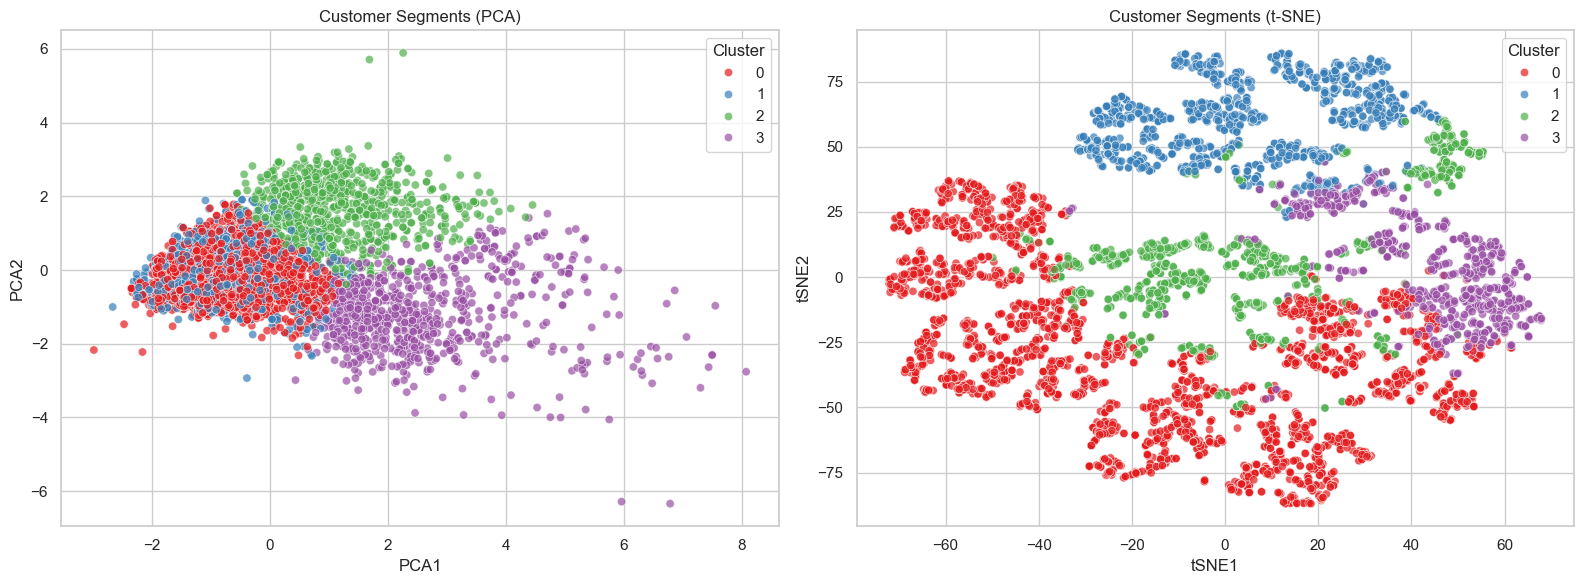

In [198]:
# PCA
pca = PCA(n_components=2, random_state=42)
pca_res = pca.fit_transform(X_scaled)
df_cluster['PCA1'] = pca_res[:, 0]
df_cluster['PCA2'] = pca_res[:, 1]

# t-SNE (Sampled for performance if dataset is large, but 5k is fine)
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
tsne_res = tsne.fit_transform(X_scaled)
df_cluster['tSNE1'] = tsne_res[:, 0]
df_cluster['tSNE2'] = tsne_res[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_cluster, palette='Set1', ax=ax[0], alpha=0.7)
ax[0].set_title('Customer Segments (PCA)')

# Plot t-SNE
sns.scatterplot(x='tSNE1', y='tSNE2', hue='Cluster', data=df_cluster, palette='Set1', ax=ax[1], alpha=0.7)
ax[1].set_title('Customer Segments (t-SNE)')

plt.tight_layout()
plt.show()


### 10.3.1 การกระจายตัวของ Churn บน t-SNE
เรามาดูกันว่าลูกค้าที่ยกเลิกการใช้บริการ (Churn = 1) กระจายตัวอย่างไรในแต่ละ Cluster เมื่อพล็อตกราฟ t-SNE

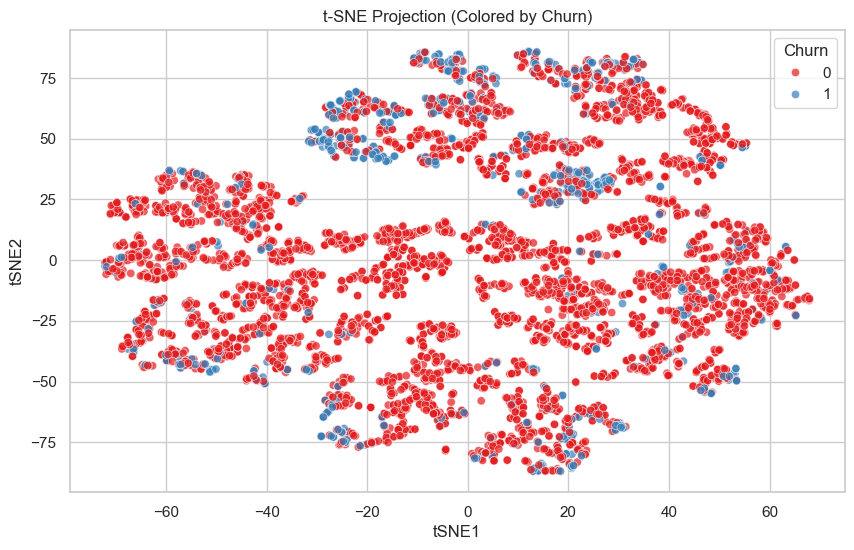

In [199]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tSNE1', y='tSNE2', hue='Churn', data=df_cluster, palette='Set1', alpha=0.7)
plt.title('t-SNE Projection (Colored by Churn)')
plt.show()

## 10.4 ข้อมูลเชิงธุรกิจและกลยุทธ์แนะนำตาม Customer Segment

จาก cluster summary ข้างต้น เราสามารถระบุ "บุคลิกลักษณะ" ของลูกค้าแต่ละกลุ่มและวางกลยุทธ์ได้ดังนี้:

**Cluster 0: "High-Value Loyalists" — ลูกค้าขาประจำมูลค่าสูง**
- **ลักษณะ:** สั่งซื้อบ่อย (OrderCount สูง), ได้ Cashback มาก, อยู่กับแพลตฟอร์มมานาน (Tenure สูง) และมี Churn rate ต่ำ
- **แนวทาง:** รักษาและให้รางวัล ไม่จำเป็นต้องแจก coupon มาก เสนอสิทธิ์ VIP, Early Access สินค้าใหม่ หรือสินค้า Premium สุดพิเศษ เป็นกลุ่มที่ push สินค้า high-margin ได้ดีที่สุด

**Cluster 1: "At-Risk / Recent Churners" — ลูกค้าเสี่ยง churn**
- **ลักษณะ:** Churn rate สูง มักเพิ่งซื้อล่าสุด (DaySinceLastOrder ต่ำ) แต่ความพึงพอใจต่ำหรือมีการร้องเรียน
- **แนวทาง:** ทำ Win-back campaign ลูกค้ากลุ่มนี้น่าจะไม่พอใจ **อย่า** ส่ง coupon ทั่วไป ควรแก้ปัญหาตรงจุด แล้วเสนอ coupon "We Miss You" พร้อมส่วนลดลึกในหมวดที่เคยซื้อ เช่น Mobile/Laptop เพื่อสร้างความเชื่อมั่นใหม่

**Cluster 2: "Coupon-Driven Bargain Hunters" — นักล่าดีล**
- **ลักษณะ:** ใช้ Coupon บ่อย (CouponUsed สูง), OrderCount ปานกลาง ซื้อเมื่อมีโปรโมชัน
- **แนวทาง:** ทำโปรโมชันแบบ targeted ส่ง coupon สม่ำเสมอและมีกำหนดเวลา มี Churn risk สูงถ้าโปรหยุด push สินค้าคงคลังที่ต้องระบาย หรือทำ bundle deal เพื่อเพิ่มมูลค่าตะกร้า

**Cluster 3: "New / Low Engagement" — ลูกค้าใหม่ยังไม่คุ้นชิน**
- **ลักษณะ:** Tenure ต่ำ, OrderCount น้อย ยังไม่ติดนิสัยการใช้แพลตฟอร์ม
- **แนวทาง:** Onboarding และ Activation ให้ส่วนลดเดือนแรกอย่างจริงจัง เช่น 20% off คำสั่งซื้อต่อไป push สินค้ายอดนิยม Conversion สูงเพื่อสร้างความคุ้นเคย ถ้าไม่ engage ใน 30 วัน อาจปล่อยให้ไปได้

### สรุปกลยุทธ์ Coupon:
- **ใครควรได้ coupon:** Cluster 2 (Bargain Hunters) เพื่อรักษา volume, Cluster 3 (New) เพื่อ activation, Cluster 1 (At-Risk) ต้องการ coupon win-back แบบ targeted
- **ใครข้ามไปได้ (ประหยัด margin):** Cluster 0 (Loyalists) ซื้ออยู่แล้ว รางวัลพวกเขาด้วย experience ไม่ใช่ discount
- **สินค้าที่ควร push:** High-margin → Cluster 0, Clearance/Bundle → Cluster 2, Popular/Gateway items → Cluster 3

In [200]:

# --- Cluster Feature Statistics: Mean / Min / Max per Segment ---
cluster_labels = {
    0: "Cluster 0: High-Value Loyalists",
    1: "Cluster 1: At-Risk / Recent Churners",
    2: "Cluster 2: Coupon-Driven Bargain Hunters",
    3: "Cluster 3: New / Low Engagement"
}

stat_cols = ['DaySinceLastOrder', 'OrderCount', 'CashbackAmount',
             'Tenure', 'CouponUsed', 'Complain', 'SatisfactionScore', 'Churn']

# Build a multi-level summary table: rows = Cluster, columns = (feature, stat)
cluster_stats = (
    df_cluster.groupby('Cluster')[stat_cols]
    .agg(['mean', 'min', 'max'])
    .round(2)
)

# Rename index with friendly labels
cluster_stats.index = [cluster_labels[i] for i in cluster_stats.index]

# Style the table for readability
styled = (
    cluster_stats.style
    .set_caption("📊 Feature Statistics by Customer Segment (Mean / Min / Max)")
    .format(precision=2)
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2c3e50')]},
        {'selector': 'th.col_heading',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('font-size', '12px')]},
        {'selector': 'th.row_heading',
         'props': [('background-color', '#ecf0f1'), ('font-weight', 'bold'),
                   ('font-size', '11px'), ('text-align', 'left')]},
        {'selector': 'td',
         'props': [('font-size', '11px'), ('text-align', 'center')]},
    ])
    .background_gradient(subset=pd.IndexSlice[:, [('CashbackAmount','mean'), ('OrderCount','mean'), ('Tenure','mean')]],
                         cmap='Blues', axis=0)
    .background_gradient(subset=pd.IndexSlice[:, [('Churn','mean'), ('Complain','mean')]],
                         cmap='Reds', axis=0)
)

display(styled)

# --- Quick per-cluster printout for easy reading ---
print("\n" + "="*80)
print("CLUSTER FEATURE SUMMARY  (mean | min | max)")
print("="*80)
for cluster_id in sorted(df_cluster['Cluster'].unique()):
    sub = df_cluster[df_cluster['Cluster'] == cluster_id][stat_cols]
    n = len(sub)
    print(f"\n{cluster_labels[cluster_id]}  (n={n:,})")
    print("-"*60)
    print(f"{'Feature':<25} {'Mean':>10} {'Min':>10} {'Max':>10}")
    print("-"*60)
    for col in stat_cols:
        print(f"  {col:<23} {sub[col].mean():>10.2f} {sub[col].min():>10.2f} {sub[col].max():>10.2f}")
print("="*80)



CLUSTER FEATURE SUMMARY  (mean | min | max)

Cluster 0: High-Value Loyalists  (n=2,777)
------------------------------------------------------------
Feature                         Mean        Min        Max
------------------------------------------------------------
  DaySinceLastOrder             3.51       0.00      15.00
  OrderCount                    1.90       1.00       8.00
  CashbackAmount              156.12       0.00     283.00
  Tenure                        7.11       0.00      30.00
  CouponUsed                    1.12       0.00       4.00
  Complain                      0.00       0.00       0.00
  SatisfactionScore             3.10       1.00       5.00
  Churn                         0.14       0.00       1.00

Cluster 1: At-Risk / Recent Churners  (n=1,197)
------------------------------------------------------------
Feature                         Mean        Min        Max
------------------------------------------------------------
  DaySinceLastOrder         

## 10.5 ความนิยมในหมวดสินค้าแยกตาม Segment

เพื่อให้กลยุทธ์ coupon ได้ผลจริง เราต้องรู้ด้วยว่าแต่ละ cluster ชอบซื้อ *อะไร* มาเชื่อม `PreferedOrderCat` กลับเข้ากับข้อมูล cluster แล้ววิเคราะห์ pattern

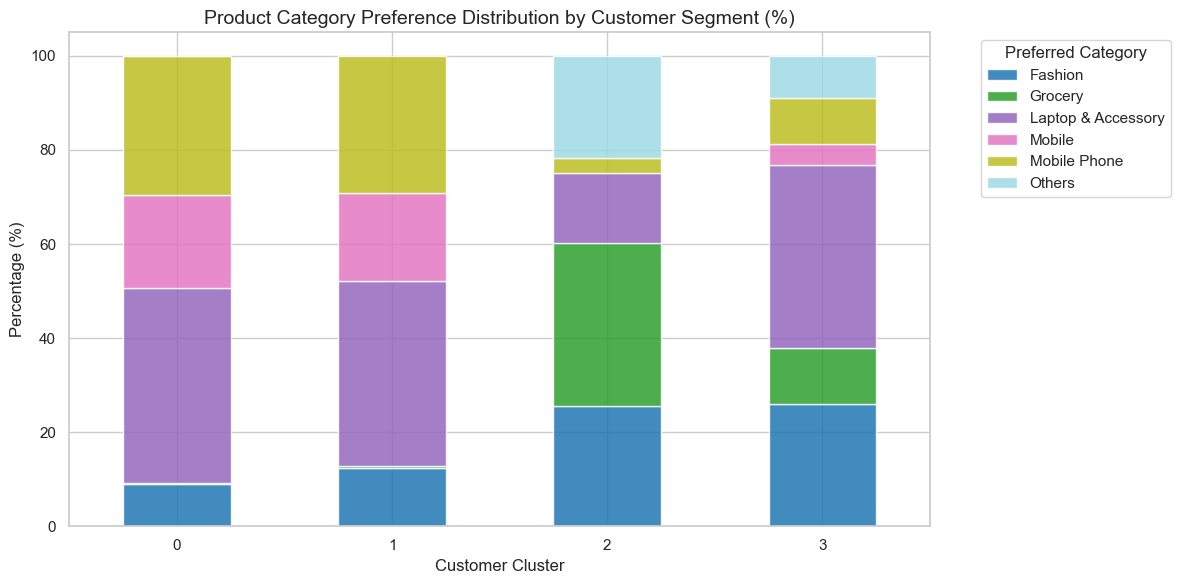

PreferedOrderCat,Fashion,Grocery,Laptop & Accessory,Mobile,Mobile Phone,Others
Cluster,,,,,,
0,9.0,0.1,41.4,19.8,29.5,0.0
1,12.4,0.4,39.2,18.8,29.2,0.0
2,25.5,34.7,14.9,0.0,3.2,21.7
3,26.0,11.9,39.0,4.3,9.7,9.1


In [201]:
# Add Category back to the cluster dataframe
# Note: Ensure the indices align since df_cluster had nulls dropped
df_cluster['PreferedOrderCat'] = df_clean.loc[df_cluster.index, 'PreferedOrderCat'] if 'df_clean' in locals() else pd.read_csv('data/Ecommerce Customer Churn.csv').loc[df_cluster.index, 'PreferedOrderCat']

# Calculate distribution of categories per cluster
category_dist = pd.crosstab(df_cluster['Cluster'], df_cluster['PreferedOrderCat'], normalize='index') * 100

# Plotting the stacked bar chart for category preferences
plt.figure(figsize=(12, 6))
category_dist.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20', alpha=0.85)

plt.title('Product Category Preference Distribution by Customer Segment (%)', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Customer Cluster', fontsize=12)
plt.legend(title='Preferred Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(category_dist.round(1))


## 10.6 กลยุทธ์สินค้าและ Coupon เชิงลึก

จาก distribution ของสินค้าในแต่ละ cluster เราสามารถออกแบบกลยุทธ์ได้ละเอียดขึ้น:

**สิ่งที่สังเกตได้:**
1. **Mobiles / Mobile Phones** โดยรวมมี Churn risk สูงกว่า Grocery หรือ Laptops
2. Cluster ที่เน้น **Laptop & Accessory** มักซื้อสินค้าราคาสูงแต่ซื้อไม่บ่อย ซึ่งอธิบายได้ว่าทำไมมูลค่าสูงแต่ recency ยาว

**กลยุทธ์ push สินค้าตาม Cluster:**

- **Cluster 0 ("High-Value Loyalists" — ขาประจำ)**
  - *ซื้ออะไร:* Laptop และ Accessories เป็นหลัก
  - *กลยุทธ์:* **Push 70% Premium/Accessories, 30% Cross-sell** ไม่ต้องลด price มาก ให้ "Early Access" สินค้า tech ใหม่แทน % off coupon

- **Cluster 1 ("At-Risk / Recent Churners" — เสี่ยง churn)**
  - *ซื้ออะไร:* มักมี spike ที่ Mobile Phones กลุ่มนี้ volatile มาก
  - *กลยุทธ์:* **Push 80% Win-back core items, 20% Essentials** ถ้าซื้อมือถือแล้ว churn อาจมีประสบการณ์แย่ เสนอ "เราขอโทษ ลด 30% Mobile Accessory ชิ้นต่อไป" เป้าหมายคือสร้างความไว้วางใจก่อน

- **Cluster 2 ("Coupon-Driven Bargain Hunters" — นักล่าดีล)**
  - *ซื้ออะไร:* กระจายใน Fashion และ Mobiles ตามโปรโมชัน
  - *กลยุทธ์:* **Push 60% Clearance/High-Inventory, 40% Fashion bundles** เขาไม่สน model ล่าสุด แค่อยากได้ "ดีล" เสนอ BOGO บน Fashion หรือลดลึกมือถือ model เก่า ทำ coupon ขั้นต่ำ (เช่น "ลด 600 เมื่อซื้อครบ 3,000") เพื่อเพิ่มมูลค่าตะกร้า

- **Cluster 3 ("New / Low Engagement" — ลูกค้าใหม่)**
  - *ซื้ออะไร:* มักเริ่มจาก Gateway items เช่น Grocery หรือ Accessories พื้นฐาน
  - *กลยุทธ์:* **Push 90% High-Conversion / Gateway items** อย่าเพิ่งเสนอ laptop ราคาแพง push FMCG (Grocery/Basic Fashion) พร้อม coupon "เดือนแรกลด 20%" เพื่อสร้างนิสัยซื้อซ้ำ

**ควรปล่อย churn บางคนไหม?**
ถ้าลูกค้าอยู่ใน **Cluster 1** หรือ **Cluster 3** ซื้อสินค้า low-margin (เช่น grocery), ร้องเรียน, และไม่กลับมาหลังรับ win-back coupon แล้ว — ควร **หยุดส่ง marketing และปล่อยให้ churn** เพราะต้นทุนรักษาลูกค้ากลุ่มนี้ไม่คุ้มกับมูลค่าที่ได้คืน

## 10.7 เจาะลึก: Cluster 0 (Loyalists) vs Cluster 1 (At-Risk)

มาดูให้ชัดขึ้นว่าอะไรคือความต่างระหว่าง "High-Value Loyalists" (Cluster 0) กับ "At-Risk / Recent Churners" (Cluster 1) โดยพล็อต `Tenure` (อยู่กับแพลตฟอร์มมานานแค่ไหน) เทียบกับ `CashbackAmount` (ใช้แทนมูลค่าการใช้จ่าย)

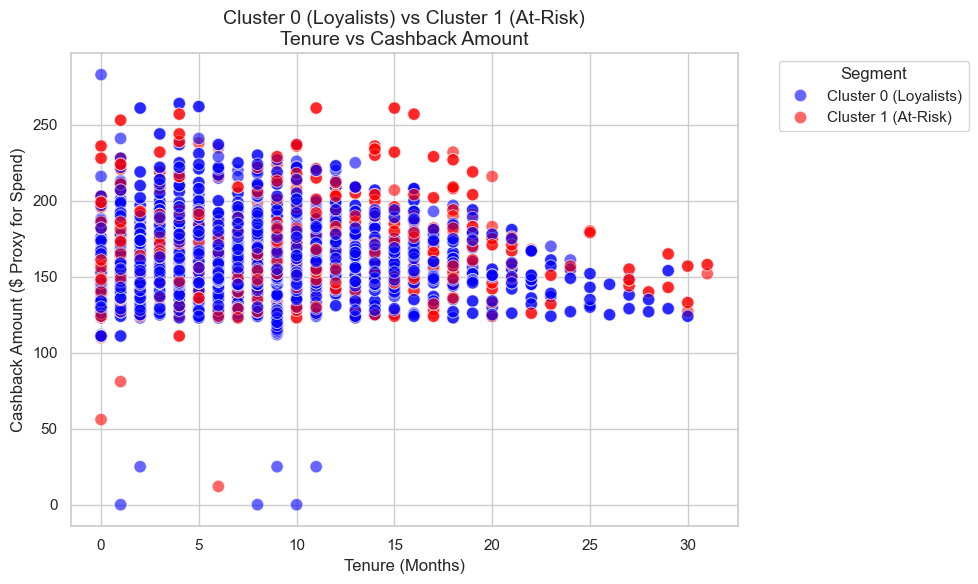

In [202]:
# Filter data for only Cluster 0 and Cluster 1
df_01 = df_cluster[df_cluster['Cluster'].isin([0, 1])]

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_01,
    x='Tenure',
    y='CashbackAmount',
    hue='Cluster',
    palette={0: 'blue', 1: 'red'},
    alpha=0.6,
    s=80,
    edgecolor='w'
)

plt.title('Cluster 0 (Loyalists) vs Cluster 1 (At-Risk)\nTenure vs Cashback Amount', fontsize=14)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Cashback Amount ($ Proxy for Spend)', fontsize=12)

# Custom legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Cluster 0 (Loyalists)', 'Cluster 1 (At-Risk)'], title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


✅ ใช้ font: Thonburi


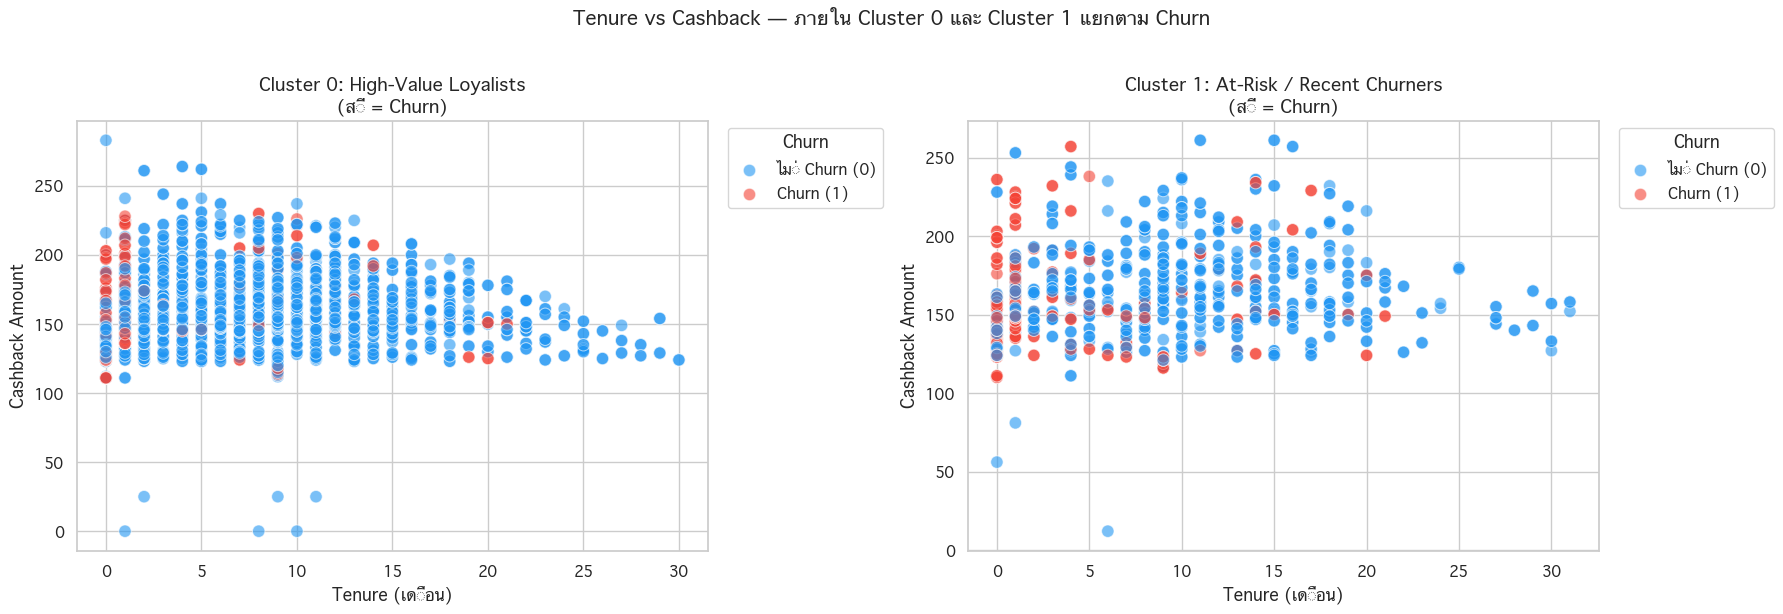

Cluster 0 (Loyalists)  →  จำนวน 2,777 คน  |  Churn Rate = 13.5%
Cluster 1 (At-Risk)  →  จำนวน 1,197 คน  |  Churn Rate = 36.4%


In [203]:

import matplotlib.font_manager as fm

# --- ตั้งค่า font รองรับภาษาไทย ---
_thai_candidates = ['Thonburi', 'Tahoma', 'Noto Sans Thai', 'Arial Unicode MS',
                    'TH Sarabun New', 'TH SarabunPSK', 'Leelawadee UI', 'FreeSans']
_available_fonts  = {f.name for f in fm.fontManager.ttflist}
_thai_font = next((f for f in _thai_candidates if f in _available_fonts), None)

if _thai_font:
    plt.rcParams['font.family'] = _thai_font
    print(f"✅ ใช้ font: {_thai_font}")
else:
    print("⚠️  ไม่พบ Thai font ในระบบ — ข้อความภาษาไทยอาจแสดงเป็น □")

# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left: Cluster 0 only — colored by Churn ---
df_c0 = df_cluster[df_cluster['Cluster'] == 0]
sns.scatterplot(
    data=df_c0, x='Tenure', y='CashbackAmount',
    hue='Churn', palette={0: '#2196F3', 1: '#F44336'},
    alpha=0.6, s=80, edgecolor='w', ax=axes[0]
)
axes[0].set_title('Cluster 0: High-Value Loyalists\n(สี = Churn)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (เดือน)')
axes[0].set_ylabel('Cashback Amount')
handles0, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles0, labels=['ไม่ Churn (0)', 'Churn (1)'],
               title='Churn', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- Right: Cluster 1 only — colored by Churn ---
df_c1 = df_cluster[df_cluster['Cluster'] == 1]
sns.scatterplot(
    data=df_c1, x='Tenure', y='CashbackAmount',
    hue='Churn', palette={0: '#2196F3', 1: '#F44336'},
    alpha=0.6, s=80, edgecolor='w', ax=axes[1]
)
axes[1].set_title('Cluster 1: At-Risk / Recent Churners\n(สี = Churn)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (เดือน)')
axes[1].set_ylabel('Cashback Amount')
handles1, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles1, labels=['ไม่ Churn (0)', 'Churn (1)'],
               title='Churn', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Tenure vs Cashback — ภายใน Cluster 0 และ Cluster 1 แยกตาม Churn',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# สรุปสัดส่วน Churn ภายในแต่ละ cluster
for cid, label in [(0, 'Cluster 0 (Loyalists)'), (1, 'Cluster 1 (At-Risk)')]:
    sub = df_cluster[df_cluster['Cluster'] == cid]
    churn_pct = sub['Churn'].mean() * 100
    print(f"{label}  →  จำนวน {len(sub):,} คน  |  Churn Rate = {churn_pct:.1f}%")


### สรุปสิ่งที่เห็นจาก Scatter Plot:

1. **ช่องว่างด้าน Tenure:** Cluster 1 (แดง) กระจุกตัวทางซ้าย (Tenure ต่ำ) — ลูกค้ากลุ่มนี้เป็นคนใหม่ที่ churn หรือเสี่ยง churn เร็ว ส่วน Cluster 0 (น้ำเงิน) กระจายออกไปทางขวา แสดงถึงความภักดีระยะยาว
2. **ช่องว่างด้านการใช้จ่าย:** Cluster 0 มี `CashbackAmount` ขั้นต่ำสูงกว่ากลุ่มแน่นของ Cluster 1 ที่อยู่ด้านล่าง แสดงว่า Loyalists ใช้จ่ายสม่ำเสมอมากกว่า
3. **บทสรุป:** ความต่างระหว่างสองกลุ่มนี้ไม่ใช่แค่ว่าคนหนึ่งซื้อ Laptop อีกคนซื้อมือถือ แต่คือ **Cluster 1 ล้มเหลวในการ "mature"** เข้ามา ใช้จ่ายน้อย แล้วออกไปเร็ว — Win-back coupon สำหรับ Cluster 1 จึงต้องเกิดขึ้น **เร็ว** ก่อนที่พวกเขาจะออกไปถาวร